# 🚕 Análisis de Datos — Trabajo Práctico Integrador
## Yellow Taxi NYC · ¿Cuánta propina dejará el pasajero?

**CEIA-FIUBA · Análisis de Datos · 2B 2026 · Grupo N.º 13**

**Integrantes:** Fioranelli, Rocío · Lerner, Federico · Makk, Azul · Moguilner Reh, Nicolás · Varela, Gustavo

---

### El hilo conductor del trabajo

Todo el notebook gira alrededor de **una sola pregunta de negocio**:

> 💡 **¿Podemos anticipar cuánta propina (`tip_amount`, en dólares) dejará un pasajero de taxi amarillo, y qué factores la explican?**

A partir de los registros oficiales de viajes de la **NYC TLC** (marzo 2026, ~3,9 millones de viajes), vamos a recorrer **de principio a fin el flujo de trabajo del análisis de datos** que vimos en la **Clase 1**:

1. **Identificar el problema** → regresión de la propina (Sección 3).
2. **Recopilar los datos** → dataset oficial TLC ya versionado en el repo.
3. **EDA y limpieza básica** → Secciones 1 y 2 (entender) y 4 (limpiar).
4. **Análisis estadístico y preparación** → Secciones 4, 5 y 6 (preprocesar, crear features, reducir dimensión).
5. **Entrenar modelos** → 🚫 **fuera de alcance**: la consigna pide *analizar y preparar* los datos, **no entrenar**. Dejamos el dataset listo para modelar y ahí cerramos.

### Mapa del notebook

| Sección | Qué hacemos | Consigna que cubre |
|---|---|---|
| **1. Exploración** | Entender estructura, tipos, faltantes, errores y outliers | Exploración y comprensión |
| **2. Visualización** | De gráficos simples a incisivos, hasta los hallazgos clave | Técnicas de visualización |
| **3. Planteo del problema** | Definir target y tipo de problema (regresión) | Problema de ML supervisado |
| **4. Preprocesamiento** | Limpiar, *split* train/test, outliers | Preprocesamiento y limpieza |
| **5. Feature engineering** | Crear features, discretizar, codificar, escalar | Feature engineering |
| **6. Reducción de dimensión** | Selección por filtros + PCA | Reducción de dimensionalidad |
| **7. Dataset listo** | Resumen del entregable para modelar | (cierre del preprocesamiento) |
| **8. Conclusiones** | Qué aprendimos y qué sigue | Conclusiones |

> **Criterio metodológico transversal — estadística robusta (Clases 2 y 3).** El dataset tiene colas larguísimas y errores extremos. Por eso, en todo el trabajo priorizamos **medidas robustas** (mediana, IQR, MAD) y **correlaciones de rangos** (Spearman, Kendall) por sobre las clásicas (media, desvío, Pearson), que los outliers distorsionan. Esta decisión se justifica con evidencia a lo largo del EDA.

## 📖 Diccionario de datos — NYC TLC Trip Records

Antes de tocar una sola celda de código conviene **leer qué significa cada columna**: es el paso 2 del flujo (comprender la fuente). Trabajamos con la versión **actualizada** del diccionario oficial de la TLC, porque el esquema cambió en 2025–2026 (ver §1.6).

Fuente: [NYC TLC Trip Record Data](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page)

| Campo | Descripción |
|---|---|
| `VendorID` | Proveedor del registro (1=CMT, 2=Curb, 6=Myle, 7=Helix). |
| `tpep_pickup_datetime` / `tpep_dropoff_datetime` | Fecha-hora de inicio y fin del viaje (taxímetro). |
| `passenger_count` | Cantidad de pasajeros declarada. |
| `trip_distance` | Distancia recorrida en millas (taxímetro). |
| `RatecodeID` | Código de tarifa (1=Estándar, 2=JFK, 3=Newark, 4=Nassau/Westchester, 5=Negociada, 6=Grupo, 99=Nulo). |
| `store_and_fwd_flag` | Viaje guardado en memoria del vehículo antes de enviarse (Y/N). |
| `PULocationID` / `DOLocationID` | Zona TLC de origen / destino. |
| `payment_type` | Medio de pago (0=Flex Fare, 1=Tarjeta, 2=Efectivo, 3=Sin cargo, 4=Disputa, 5=Desconocido, 6=Anulado). |
| `fare_amount` | Tarifa por tiempo y distancia calculada por el taxímetro. |
| `extra`, `mta_tax`, `improvement_surcharge`, `congestion_surcharge`, `cbd_congestion_fee`, `airport_fee`, `tolls_amount` | Recargos, impuestos y peajes. |
| `tip_amount` | **Propina. Solo se registra automáticamente en pagos con tarjeta; las propinas en efectivo NO se incluyen.** ← clave para nuestro target. |
| `total_amount` | Total cobrado (incluye la propina; **no** incluye propinas en efectivo). |

## 🔍 Exploración preliminar — primer contacto con los datos en crudo

**Concepto.** Antes de cualquier análisis fino, hacemos un *reconocimiento de terreno*: cargar el archivo, mirar las primeras filas, las dimensiones, los tipos de dato y dónde hay nulos. Es el equivalente a "abrir la caja y ver qué hay adentro". Acá todavía **no limpiamos ni decidimos nada**: solo observamos para saber a qué nos enfrentamos.

In [1]:
# Importamos las librerías del flujo de trabajo (Clase 1):
# pandas/numpy para manipular datos, matplotlib/seaborn para visualizar,
# scipy/sklearn para estadística y preparación. Cargamos cada una donde se usa.

from pathlib import Path
import pandas as pd
from pandas.api.types import CategoricalDtype
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats as st
from scipy.stats import describe

**Carga del dataset.** Leemos el *parquet* oficial (formato columnar, eficiente para millones de filas) y miramos las primeras 5 observaciones para confirmar que cargó bien y reconocer las columnas del diccionario.

In [2]:
# Mostramos las primeras 5 filas: control visual de que el parquet cargó OK
# y de que las columnas coinciden con el diccionario de datos.

# Mostramos el dataset y sus columnas con los primeros 5 registros
DATA_PATH = Path("dataset") / "yellow_tripdata_2026-03.parquet"
df = pd.read_parquet(DATA_PATH)
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-03-01 00:02:26,2026-03-01 00:13:45,1.0,2.58,1.0,N,48,151,1,14.2,1.0,0.5,4.99,0.0,1.0,24.94,2.5,0.0,0.75
1,2,2026-03-01 00:19:33,2026-03-01 00:28:21,1.0,1.50,1.0,N,238,166,1,10.0,1.0,0.5,0.00,0.0,1.0,15.00,2.5,0.0,0.00
2,2,2026-03-01 00:07:20,2026-03-01 00:15:12,2.0,0.88,1.0,N,90,249,1,8.6,1.0,0.5,2.87,0.0,1.0,17.22,2.5,0.0,0.75
3,2,2026-03-01 00:16:11,2026-03-01 00:28:20,1.0,1.76,1.0,N,249,137,1,12.1,1.0,0.5,3.57,0.0,1.0,21.42,2.5,0.0,0.75
4,2,2026-03-01 00:20:47,2026-03-01 00:30:44,2.0,1.57,1.0,N,100,142,1,11.4,1.0,0.5,3.43,0.0,1.0,20.58,2.5,0.0,0.75


**Dimensiones y tipos.** ¿Cuántas observaciones y variables tenemos? ¿Qué tipo asignó pandas a cada columna? Esto orienta el resto del análisis (Clase 1: filas = observaciones, columnas = variables).

In [3]:
# shape = (filas, columnas). dtypes = tipo de dato inferido por pandas para cada columna.

# Mostramos la cantidad de filas y columnas, y el tipo de dato de cada columna
print("Filas, columnas:", df.shape)
df.dtypes

Filas, columnas: (3952451, 20)


VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
cbd_congestion_fee              float64
dtype: object

**Huella de memoria.** Con ~4 millones de filas conviene saber cuánta RAM ocupa: condiciona qué operaciones son viables (Clase 1: las bibliotecas de Python y la eficiencia).

In [4]:
# memory_usage='deep' contabiliza también el costo real de las columnas de texto/objeto.

# Mostramos la memoria que ocupa el dataset
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3952451 entries, 0 to 3952450
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

**Estadística descriptiva rápida.** Un `describe()` global da una primera foto de rangos y escalas. Spoiler: ya van a saltar valores absurdos (mínimos negativos, máximos gigantes) que motivan toda la limpieza posterior.

In [5]:
# describe() resume conteo, media, desvío, mín, cuartiles y máx de las columnas numéricas.
# Redondeamos a 2 decimales para que la tabla sea legible.

# Mostramos la estadistica descriptiva del dataset
df.describe().round(2)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
count,3952451.00,3952451,3952451,3006703.00,3952451.00,3006703.00,3952451.00,3952451.00,3952451.00,3952451.00,3952451.00,3952451.00,3952451.00,3952451.00,3952451.00,3952451.00,3006703.00,3006703.00,3952451.00
mean,1.88,2026-03-16 09:09:15.947559,2026-03-16 09:26:33.369682,1.23,5.98,5.64,161.51,160.86,0.88,21.33,1.12,0.49,2.86,0.53,0.95,30.10,2.19,0.16,0.53
min,1.00,2008-12-31 23:03:20,2009-01-01 00:07:36,0.00,0.00,1.00,1.00,1.00,0.00,-990.00,-7.50,-0.50,-75.75,-111.79,-1.00,-1022.46,-2.50,-2.00,-0.75
25%,2.00,2026-03-08 17:38:26,2026-03-08 17:55:32,1.00,1.01,1.00,114.00,107.00,1.00,10.00,0.00,0.50,0.00,0.00,1.00,17.22,2.50,0.00,0.00
50%,2.00,2026-03-16 08:13:05,2026-03-16 08:32:14,1.00,1.82,1.00,161.00,162.00,1.00,15.60,0.00,0.50,2.11,0.00,1.00,23.40,2.50,0.00,0.75
75%,2.00,2026-03-23 17:55:51.500000,2026-03-23 18:13:19,1.00,3.71,1.00,233.00,234.00,1.00,26.80,2.50,0.50,3.95,0.00,1.00,34.90,2.50,0.00,0.75
max,7.00,2026-04-01 00:06:25,2026-04-02 16:03:47,8.00,288381.68,99.00,265.00,265.00,4.00,1843.30,17.46,4.75,397.00,1400.00,1.00,1850.55,2.50,27.00,0.75
std,0.72,NaN,NaN,0.63,581.05,20.59,66.57,70.71,0.63,18.69,1.75,0.09,3.91,2.29,0.24,22.41,0.87,0.55,0.35


**¿Dónde hay datos faltantes?** Listamos solo las columnas con nulos. En §1.3 vamos a investigar *por qué* faltan (su mecanismo: MCAR/MAR/MNAR, Clase 3).

In [6]:
# isna().sum() cuenta nulos por columna; nos quedamos solo con las que tienen > 0.

# Mostramos la cantidad de nulos de aquellas columnas que tienen nulos
nulos = df.isna().sum().sort_values(ascending=False)
nulos[nulos > 0]

Airport_fee             945748
passenger_count         945748
congestion_surcharge    945748
RatecodeID              945748
store_and_fwd_flag      945748
dtype: int64

**Sondeos puntuales.** Antes del análisis formal, un par de preguntas sueltas que despiertan sospechas: ¿cuántos pasajeros entran en un taxi? ¿cómo se reparten los medios de pago? ¿cómo se ve la propina?

In [7]:
# Sondeo de passenger_count: ¿hay valores raros (0, o cantidades imposibles de pasajeros)?

print('Cantidad máxima de pasajeros transportados en un viaje:', (df['passenger_count']).max())

print('Viajes con +2 pasajeros', (df['passenger_count'] > 2).sum())

print('Viajes con +3 pasajeros', (df['passenger_count'] > 3).sum())

print('Viajes con +4 pasajeros', (df['passenger_count'] > 4).sum())

print('Viajes con +5 pasajeros', (df['passenger_count'] > 5).sum())

print('Viajes con +5 pasajeros', (df['passenger_count'] > 7).sum())

# Descripción de la columna passenger_count
df['passenger_count'].describe()

Cantidad máxima de pasajeros transportados en un viaje: 8.0
Viajes con +2 pasajeros 137659
Viajes con +3 pasajeros 61761
Viajes con +4 pasajeros 13612
Viajes con +5 pasajeros 5130
Viajes con +5 pasajeros 3


count    3.006703e+06
mean     1.230823e+00
std      6.330375e-01
min      0.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      8.000000e+00
Name: passenger_count, dtype: float64

In [8]:
# Sondeo de payment_type: describe() de los códigos de medio de pago (ver leyenda abajo).

# Descripción de la columna payment_type
df['payment_type'].describe()

# 0: Flex Fare trip
# 1: Credit card
# 2: Cash
# 3: No charge
# 4: Dispute
# 5: Unknown
# 6: Voided trip

count    3.952451e+06
mean     8.805670e-01
std      6.317968e-01
min      0.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      4.000000e+00
Name: payment_type, dtype: float64

**Primer gráfico (simple) — reparto de medios de pago.** Empezamos la exploración visual por lo más básico: un *countplot* (Clase 2, gráfico apropiado para una variable categórica). Nos dice cuál es el medio de pago dominante.

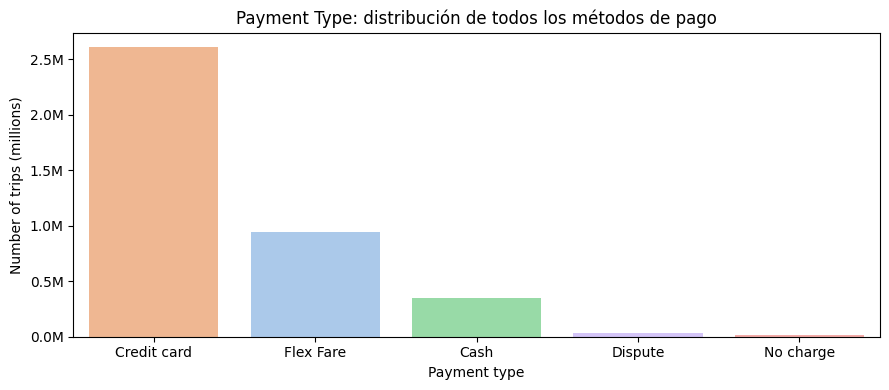

In [9]:
# countplot = conteo por categoría (Clase 2). Etiquetamos los códigos para que se lea claro.

# Distribución de todos los métodos de pago (payment_type)
payment_labels = {
    0: 'Flex Fare',
    1: 'Credit card',
    2: 'Cash',
    3: 'No charge',
    4: 'Dispute',
    5: 'Unknown',
    6: 'Voided trip',
}

# Orden por frecuencia descendente, considerando solo los códigos presentes
order = df['payment_type'].value_counts().index.tolist()

plt.figure(figsize=(9, 4))
ax = sns.countplot(
    data=df,
    x='payment_type',
    hue='payment_type',
    order=order,
    palette='pastel',
    legend=False
)

ax.set_xticks(range(len(order)))
ax.set_xticklabels([payment_labels.get(code, str(code)) for code in order])
plt.title('Payment Type: distribución de todos los métodos de pago')
plt.xlabel('Payment type')
plt.ylabel('Number of trips (millions)')

ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1_000_000:.1f}M'))

plt.tight_layout()
plt.show()

**Conclusión del gráfico.** El **pago con tarjeta domina** (~66%), seguido por Flex Fare y efectivo. Como la propina solo se registra con tarjeta, este reparto ya anticipa que vamos a trabajar sobre ese subconjunto (Sección 3).

In [10]:
# Sondeo de tip_amount: ¿hay propinas negativas? ¿qué tan dispersa está la propina?

# Muestra de la columna tip_amount
df['tip_amount'].describe()

print(f"hay {(df['tip_amount'] < 0).sum()} propinas negativas. se pagó de menos, ajuste contable?")
print(f"el 50% deja entre {df['tip_amount'].quantile(0.25)} y {df['tip_amount'].quantile(0.75)} usd de propina, el promedio es de {df['tip_amount'].mean():.2f}")
print(f"la propina máxima fue de {df['tip_amount'].max():.2f} usd")

hay 40 propinas negativas. se pagó de menos, ajuste contable?
el 50% deja entre 0.0 y 3.95 usd de propina, el promedio es de 2.86
la propina máxima fue de 397.00 usd


**Mini-conclusión de los sondeos.** Aparece la pista que decide el target: la **propina solo existe con tarjeta** y tiene **valores negativos y máximos enormes** (ruido). Ambas cosas guían el planteo del problema (§3) y la limpieza (§4).

**Escala de las variables clave (histogramas en escala log).** Para *ver* las colas extremas usamos escala logarítmica en el eje Y: con escala lineal, los outliers gigantes aplastan todo en una sola barra y no se distingue nada (conexión con la consigna 7: que el gráfico siempre muestre información).

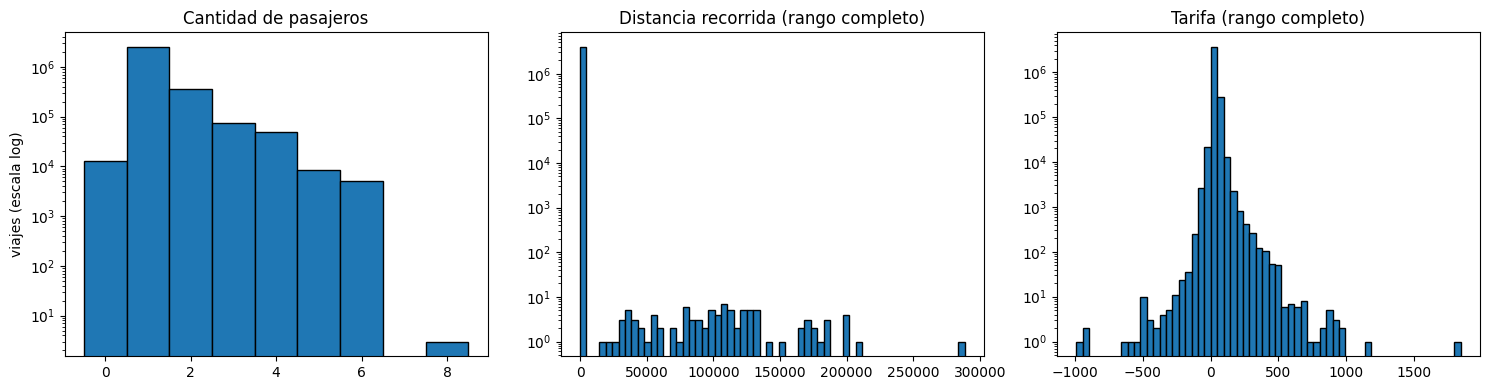

In [11]:
# Histogramas de pasajeros / distancia / tarifa en escala log-Y para revelar las colas.

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# Escala log en Y: permite ver los bins minoritarios de la cola
# (con escala lineal, los outliers extremos aplastan todo en una sola barra)
ax[0].hist(df['passenger_count'].dropna(), bins=np.arange(-0.5, 9.5, 1), edgecolor='black')
ax[0].set_title('Cantidad de pasajeros')
ax[0].set_yscale('log'); ax[0].set_ylabel('viajes (escala log)')

ax[1].hist(df['trip_distance'], bins=60, edgecolor='black')
ax[1].set_title('Distancia recorrida (rango completo)')
ax[1].set_yscale('log')

ax[2].hist(df['fare_amount'], bins=60, edgecolor='black')
ax[2].set_title('Tarifa (rango completo)')
ax[2].set_yscale('log')

plt.tight_layout()
plt.show()
# La escala log revela los outliers: distancias de hasta ~288 mil millas y
# tarifas negativas / de ~1.800 USD que en escala lineal eran invisibles.

**Conclusión.** La escala log destapa lo que la lineal escondía: distancias de **cientos de miles de millas** y tarifas **negativas o de ~1.800 USD**. Son físicamente imposibles → confirman que habrá que limpiar (§1.4 y §4).

**Cuartiles e IQR de la distancia (Clase 2).** Calculamos Q1, Q2 (mediana) y Q3, y el **rango intercuartil (IQR = Q3 − Q1)**, que contiene el 50% central de los datos y es la base de la detección robusta de outliers.

In [12]:
# Cuartiles e IQR de trip_distance: medidas robustas de posición y dispersión (Clase 2).

def cuartiles(variable):
    Q1 = variable.quantile(0.25)
    Q2 = variable.quantile(0.50)  # Percentile 5-0 - Equivalente a la mediana
    Q3 = variable.quantile(0.75)
    return Q1, Q2, Q3

trip_distance_Q1, trip_distance_Q2, trip_distance_Q3 = cuartiles(df['trip_distance'])

print("Q1 (25%):", trip_distance_Q1, "millas")
print("Q2 (Mediana, 50%):", trip_distance_Q2, "millas")
print("Q3 (75%):", trip_distance_Q3, "millas")

trip_distance_IQR = trip_distance_Q3 - trip_distance_Q1
print("Rango intercuartil (IQR):", trip_distance_IQR, "millas")

Q1 (25%): 1.01 millas
Q2 (Mediana, 50%): 1.82 millas
Q3 (75%): 3.71 millas
Rango intercuartil (IQR): 2.7 millas


**Boxplot de la distancia — completo vs. con zoom (Clase 2).** El *boxplot* muestra mediana, cuartiles y outliers. A la izquierda el rango completo (un solo outlier domina la escala); a la derecha, zoom hasta el percentil 99 para que el cuerpo de la distribución **se vea** (consigna 7).

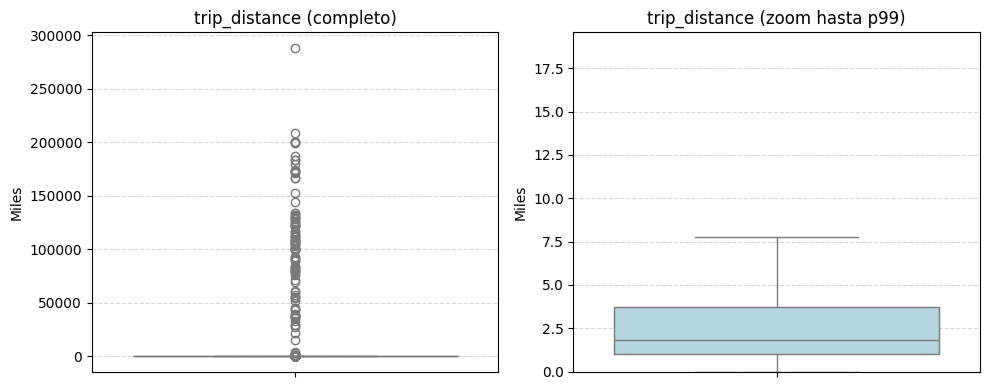

p99 de trip_distance: 19.58


In [13]:
# Boxplot de trip_distance: izq = rango completo, der = zoom hasta p99 para visibilidad.

trip_distance = df['trip_distance'].dropna()
trip_distance_pos = trip_distance[trip_distance >= 0]

p99 = trip_distance_pos.quantile(0.99)

fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharey=False)

# Boxplot completo (sin ocultar outliers)
sns.boxplot(y=trip_distance_pos, color='lightblue', ax=ax[0])
ax[0].set_title('trip_distance (completo)')
ax[0].set_ylabel('Miles')
ax[0].grid(axis='y', ls='--', alpha=0.5)

# Boxplot con zoom hasta percentil 99
sns.boxplot(y=trip_distance_pos, color='lightblue', showfliers=False, ax=ax[1])
ax[1].set_ylim(0, p99)
ax[1].set_title('trip_distance (zoom hasta p99)')
ax[1].set_ylabel('Miles')
ax[1].grid(axis='y', ls='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f'p99 de trip_distance: {p99:.2f}')

**Conclusión.** Confirmamos asimetría fuerte a derecha: la mediana es ~1,8 millas pero hay una cola larguísima. Recortar a p99 es un recurso de *visualización* (no de limpieza todavía).

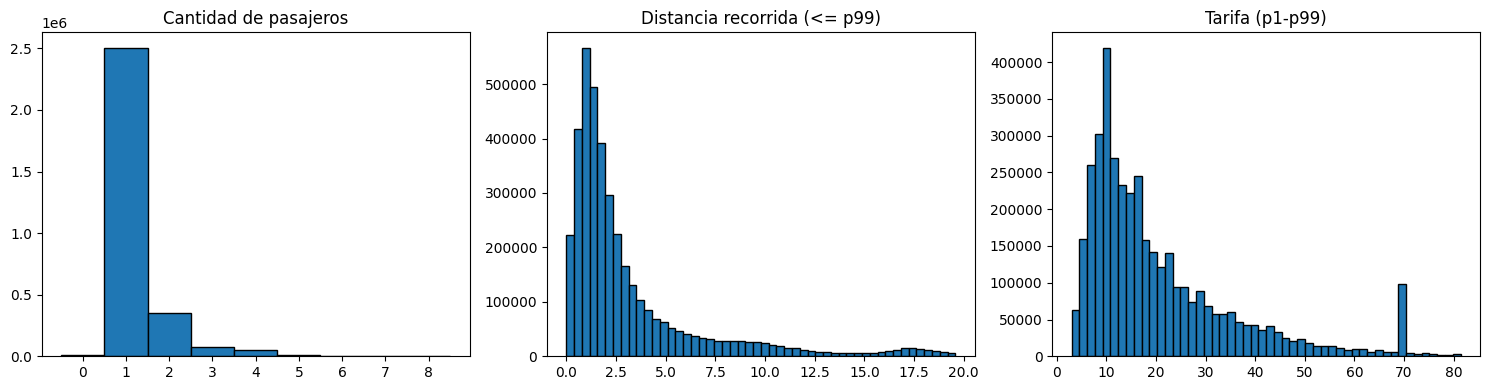

In [14]:
# Histogramas recortados a p1-p99: ahora sí se aprecia la forma real de cada distribución.

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# passenger_count como bins enteros
ax[0].hist(df['passenger_count'].dropna(), bins=np.arange(-0.5, 9.5, 1), edgecolor='black')
ax[0].set_title('Cantidad de pasajeros')
ax[0].set_xticks(range(0, 9))

# trip_distance sin extremos (p99)
d = df['trip_distance'].dropna()
d = d[(d >= 0) & (d <= d.quantile(0.99))]
ax[1].hist(d, bins=50, edgecolor='black')
ax[1].set_title('Distancia recorrida (<= p99)')

# fare_amount sin extremos (p1-p99)
f = df['fare_amount'].dropna()
f = f[(f >= f.quantile(0.01)) & (f <= f.quantile(0.99))]
ax[2].hist(f, bins=50, edgecolor='black')
ax[2].set_title('Tarifa (p1-p99)')

plt.tight_layout()
plt.show()

**Conclusión de la exploración preliminar.** Ya tenemos el panorama: ~4M de viajes, predominio de tarjeta, distribuciones muy asimétricas y **errores groseros** (negativos, valores imposibles). Con esto, pasamos al análisis **ordenado y formal** de la Sección 1.

---
## ⚙️ Configuración de visualización

**Concepto.** Fijamos un estilo único para *todos* los gráficos del notebook (tamaño, resolución y tipografía generosos) para que **siempre se lean con claridad**, sin ejes apretados ni textos diminutos. Es una decisión de comunicación: un gráfico que no se entiende no aporta evidencia.

In [15]:
# Estilo unificado y pensado para legibilidad (consigna: gráficos siempre visibles).
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook', palette='deep')
plt.rcParams.update({
    'figure.figsize': (12, 5),      # tamaño base amplio
    'figure.dpi': 110,              # resolución en pantalla
    'savefig.dpi': 110,             # resolución al exportar
    'axes.titlesize': 14, 'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'axes.spines.top': False, 'axes.spines.right': False,  # menos "tinta", más foco
})
print('Estilo de visualización configurado.')

Estilo de visualización configurado.


## 🧭 Resumen de hallazgos (qué vamos a encontrar)

Anticipamos el destino del viaje analítico. Cada hallazgo se **demuestra** más adelante con código y gráficos; esta tabla es la brújula.

| # | Hallazgo | Implicancia |
|---|----------|-------------|
| 1 | **3.952.451 viajes × 20 variables** (marzo 2026), ~750 MB en RAM | Volumen grande → exige eficiencia y muestreo en algunos gráficos |
| 2 | **23,93% de faltantes** en 5 columnas, **100% en viajes Flex Fare** (`payment_type=0`) | Faltante **MAR/estructural** (Clase 3) → se resuelve al restringir el universo a tarjeta |
| 3 | Errores físicos: duraciones ≤ 0, distancias de 288 mil millas, importes negativos, fechas de 2008 | Limpiamos lo imposible; los raros pero válidos se **acotan** (winsorización, Clase 4) |
| 4 | Pearson distancia~duración ≈ **0** vs **Spearman 0,79 / Kendall 0,63** | Los outliers rompen las medidas clásicas → **estadística robusta** (Clases 2 y 3) |
| 5 | `tip_amount` solo se registra con **tarjeta**; en efectivo es 0 siempre (**MNAR**) | Target = propina con tarjeta → universo restringido a `payment_type==1` |
| 6 | Con tarjeta, el **90,2%** deja propina; mediana **3,20 USD** (cola hasta ~400 USD) | Target = **regresión** de `tip_amount`; extremos tratados como outliers |

---
# 1. Exploración y comprensión de los datos

**De qué se trata esta sección.** Pasamos del vistazo informal a un análisis **ordenado**. El objetivo (Clase 1) es *comprender* el dataset antes de transformarlo: su estructura, los tipos de variable, qué tan confiables son las medidas, dónde y por qué faltan datos, y qué valores son errores. Todo esto define las decisiones de limpieza de la Sección 4.

### 1.1 Estructura general del dataset

**Concepto.** Primero, el "censo" del dataset: cuántas observaciones, cuántas variables y de qué **tipo** son. Pero el `dtype` crudo no alcanza: una zona codificada como número (`PULocationID`) es en realidad **categórica nominal** (Clase 1). Por eso clasificamos las variables por su *significado*, no por cómo las guardó pandas.

In [16]:
# Resumen estructural: nº de observaciones, nº de variables, memoria y tipos de dato.

# Resumen estructural: nº de observaciones, nº de variables y tipos de datos
n_obs, n_vars = df.shape
print(f'Observaciones (viajes): {n_obs:,}')
print(f'Variables (columnas):  {n_vars}')
print(f'Memoria en RAM:        {df.memory_usage(deep=True).sum()/1e6:,.1f} MB')

tipos = (df.dtypes.astype(str)
           .replace({'int32':'entero','int64':'entero','float64':'flotante',
                     'object':'texto/categórica','datetime64[us]':'fecha-hora'}))
resumen_tipos = tipos.value_counts().rename('cantidad').to_frame()
resumen_tipos

Observaciones (viajes): 3,952,451
Variables (columnas):  20
Memoria en RAM:        726.4 MB


,cantidad
flotante,13
entero,4
fecha-hora,2
texto/categórica,1


In [17]:
# Clasificación SEMÁNTICA (Clase 1): numéricas continuas/discretas vs categóricas
# nominales vs temporales. Más útil que el dtype porque varias categóricas vienen
# disfrazadas de número (VendorID, RatecodeID, payment_type, zonas).

# Clasificación semántica de las variables (más útil que el dtype crudo)
variables = {
    'numéricas continuas': ['trip_distance','fare_amount','extra','mta_tax','tip_amount',
                            'tolls_amount','improvement_surcharge','total_amount',
                            'congestion_surcharge','Airport_fee','cbd_congestion_fee'],
    'numéricas discretas': ['passenger_count'],
    'categóricas nominales': ['VendorID','RatecodeID','store_and_fwd_flag',
                              'payment_type','PULocationID','DOLocationID'],
    'temporales': ['tpep_pickup_datetime','tpep_dropoff_datetime'],
}
for tipo, cols in variables.items():
    print(f'{tipo:24s} ({len(cols)}): {cols}')

numéricas continuas      (11): ['trip_distance', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee', 'cbd_congestion_fee']
numéricas discretas      (1): ['passenger_count']
categóricas nominales    (6): ['VendorID', 'RatecodeID', 'store_and_fwd_flag', 'payment_type', 'PULocationID', 'DOLocationID']
temporales               (2): ['tpep_pickup_datetime', 'tpep_dropoff_datetime']


**Interpretación.** El dataset tiene **3.952.451 viajes** y **20 variables**. Conviven variables temporales (pickup/dropoff), numéricas de importe (la mayoría componentes de la tarifa), una numérica discreta (`passenger_count`) y varias categóricas que vienen codificadas como números (`VendorID`, `RatecodeID`, `payment_type`, `PULocationID`, `DOLocationID`). Es clave tratar a estas últimas como **categóricas**, no como números, porque su magnitud no tiene sentido aritmético (la zona 238 no es 'mayor' que la 90).

### 1.2 Estadística descriptiva — robusta vs. no robusta (Clase 2)

**Concepto.** Acá aparece, por primera vez con números, el **criterio transversal del trabajo**. La Clase 2 distingue medidas **no robustas** (media, desvío estándar), que se dejan arrastrar por valores extremos, de las **robustas** (mediana, IQR, MAD), que resisten. Comparamos ambas para *anticipar* cuánto daño hacen los outliers.

> **MAD** (*Median Absolute Deviation*, Clase 2): `mediana(|xᵢ − mediana(x)|)`. Es a la mediana lo que el desvío estándar es a la media, pero robusto.

In [18]:
# Definimos MAD (medida de dispersión robusta, Clase 2) y comparamos, para cada variable,
# las medidas clásicas (media, std) contra las robustas (mediana, IQR, MAD).

def mad(x):
    """Desviación absoluta mediana (Median Absolute Deviation), medida robusta de dispersión."""
    x = x.dropna()
    return (x - x.median()).abs().median()

num_cols = ['trip_distance','fare_amount','tip_amount','total_amount','passenger_count']
tabla = pd.DataFrame({
    'media':   [df[c].mean()   for c in num_cols],
    'mediana': [df[c].median() for c in num_cols],
    'std':     [df[c].std()    for c in num_cols],
    'IQR':     [df[c].quantile(.75)-df[c].quantile(.25) for c in num_cols],
    'MAD':     [mad(df[c])     for c in num_cols],
    'min':     [df[c].min()    for c in num_cols],
    'max':     [df[c].max()    for c in num_cols],
}, index=num_cols).round(2)
tabla

,media,mediana,std,IQR,MAD,min,max
trip_distance,5.98,1.82,581.05,2.70,1.02,0.00,288381.68
fare_amount,21.33,15.60,18.69,16.80,7.00,-990.00,1843.30
tip_amount,2.86,2.11,3.91,3.95,2.11,-75.75,397.00
total_amount,30.10,23.40,22.41,17.68,7.49,-1022.46,1850.55
passenger_count,1.23,1.00,0.63,0.00,0.00,0.00,8.00


**Interpretación.** La brecha entre **media y mediana** y entre **std e IQR/MAD** es enorme: por ejemplo `trip_distance` tiene mediana ~1,8 millas pero un máximo de **288.381 millas** (físicamente imposible), y `fare_amount` llega a ~1.843 USD. La media y el desvío están **inflados por valores extremos**, mientras que mediana, IQR y MAD se mantienen estables. Esto justifica usar estadística robusta en el resto del trabajo.

### 1.3 Valores faltantes y su tipo: MCAR / MAR / MNAR (Clase 3)

**Concepto.** No alcanza con contar nulos: hay que entender **por qué** faltan, porque eso determina cómo tratarlos (Clase 3). Los tres mecanismos:
- **MCAR** (faltan al azar, sin patrón) — no introduce sesgo.
- **MAR** (la falta depende de *otra* variable observada) — predecible/imputable.
- **MNAR** (la falta depende del *propio* valor no observado) — el caso más difícil.

Investigamos si los nulos coinciden entre columnas y si se concentran en algún grupo.

In [19]:
# Conteo de nulos y porcentaje por columna (las 5 columnas afectadas).

nulos = df.isna().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
tab_nulos = pd.DataFrame({'faltantes': nulos, 'porcentaje': (100*nulos/len(df)).round(2)})
tab_nulos

,faltantes,porcentaje
passenger_count,945748,23.93
RatecodeID,945748,23.93
store_and_fwd_flag,945748,23.93
congestion_surcharge,945748,23.93
Airport_fee,945748,23.93


In [20]:
# ¿Los nulos coinciden en las mismas filas? ¿Se concentran en algún payment_type?
# Si se concentran en una categoría observable, NO es MCAR (Clase 3).

# ¿Los faltantes coinciden entre sí y con algún valor observado?
cols_nan = ['passenger_count','RatecodeID','store_and_fwd_flag',
            'congestion_surcharge','Airport_fee']
mask = df['passenger_count'].isna()
print(f'Filas con passenger_count nulo: {mask.sum():,} ({100*mask.mean():.2f}%)')
print('¿Las 5 columnas faltan en las MISMAS filas?',
      all((df[c].isna() == mask).all() for c in cols_nan))
print()
# Relación de esos faltantes con payment_type
print('payment_type de las filas con faltantes:')
print(df.loc[mask, 'payment_type'].value_counts(normalize=True).mul(100).round(2))
print()
print('De los viajes con payment_type==0 (Flex Fare), %% con datos faltantes:',
      round(100*df.loc[df['payment_type']==0,'passenger_count'].isna().mean(),2))

Filas con passenger_count nulo: 945,748 (23.93%)
¿Las 5 columnas faltan en las MISMAS filas? True

payment_type de las filas con faltantes:
payment_type
0    100.0
Name: proportion, dtype: float64

De los viajes con payment_type==0 (Flex Fare), %% con datos faltantes: 100.0


**Interpretación (tipo de faltantes).** Las cinco columnas con nulos faltan **exactamente en las mismas 945.748 filas (23,93%)**, y esas filas son **el 100% de los viajes con `payment_type == 0` (Flex Fare)**. La ausencia no es aleatoria: depende de una variable **observada** (el canal/tipo de viaje Flex Fare, asociado a otro proveedor).

- **No es MCAR**: si fuera completamente al azar, los nulos se repartirían entre todos los tipos de pago, no se concentrarían en uno.
- **Es MAR / faltante estructural**: la probabilidad de faltante se explica por una variable observada (`payment_type`/canal Flex Fare). Conociendo esa variable, el faltante es predecible y, por lo tanto, **estructural**: en nuestro pipeline se resuelve excluyendo Flex Fare al restringir el universo a tarjeta (§4).

En cambio, los **ceros de `tip_amount` en pagos en efectivo** son un caso distinto, más cercano a **MNAR**: la propina en efectivo existe en la realidad pero **nunca se registra** (lo aclara el diccionario de datos). El valor faltante depende del propio valor no observado.

### 1.4 Errores y valores imposibles

**Concepto.** Los faltantes no son el único problema de calidad: también hay **valores imposibles** (errores de registro, GPS o reloj). Derivamos la **duración del viaje** (`dropoff − pickup`) —que además será un feature útil— y buscamos inconsistencias físicas y lógicas. La regla de oro (Clase 4): **distinguir un error de un valor legítimamente extremo.**

In [21]:
# Derivamos duration_min y contamos violaciones a reglas físicas/lógicas
# (duración <=0, distancias o importes imposibles, fechas fuera de rango).

# Duración del viaje en minutos = dropoff - pickup
df['duration_min'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds()/60

errores = {
    'duración <= 0 (dropoff <= pickup)':      (df['duration_min'] <= 0).sum(),
    'duración > 180 min (>3 h)':              (df['duration_min'] > 180).sum(),
    'trip_distance == 0':                     (df['trip_distance'] == 0).sum(),
    'trip_distance > 100 millas':             (df['trip_distance'] > 100).sum(),
    'fare_amount < 0':                        (df['fare_amount'] < 0).sum(),
    'total_amount < 0':                       (df['total_amount'] < 0).sum(),
    'tip_amount < 0':                         (df['tip_amount'] < 0).sum(),
    'passenger_count == 0':                   (df['passenger_count'] == 0).sum(),
    'pickup fuera de marzo 2026':             (~df['tpep_pickup_datetime'].between('2026-03-01','2026-03-31 23:59:59')).sum(),
}
err = pd.DataFrame({'casos': pd.Series(errores)})
err['porcentaje'] = (100*err['casos']/len(df)).round(3)
print('Rango de fechas de pickup:', df['tpep_pickup_datetime'].min(), '->', df['tpep_pickup_datetime'].max())
err

Rango de fechas de pickup: 2008-12-31 23:03:20 -> 2026-04-01 00:06:25


,casos,porcentaje
duración <= 0 (dropoff <= pickup),49133,1.243
duración > 180 min (>3 h),1181,0.030
trip_distance == 0,121210,3.067
trip_distance > 100 millas,161,0.004
fare_amount < 0,20724,0.524
total_amount < 0,21305,0.539
tip_amount < 0,40,0.001
passenger_count == 0,12967,0.328
pickup fuera de marzo 2026,19,0.000


**Interpretación.** Aparecen errores claros: **49.133 viajes (1,24%) con duración ≤ 0** (el dropoff ocurre antes que el pickup), duraciones de hasta **127 horas**, **121.210 viajes con distancia 0**, importes **negativos** en `fare_amount` y `total_amount` (≈21 mil cada uno, típicamente reembolsos/ajustes o disputas), y timestamps fuera de rango (el mínimo es de 2008). Son inconsistencias que hay que **corregir o eliminar** en la limpieza.

#### Caso de estudio — ¿los viajes con `passenger_count == 0` son mensajería?

**Concepto.** Un buen EDA no solo describe: **interroga hipótesis**. Antes de descartar los viajes "sin pasajeros" como basura, preguntamos si podrían ser un servicio real (mensajería/courier). Comparamos su comportamiento contra el resto: si fueran courier, deberían verse distintos.

In [22]:
# Comparamos viajes con 0 pasajeros vs el resto en variables reveladoras
# (proveedor, propina, distancia, duración, tipo de tarifa).

# ¿Se comportan distinto los viajes con 0 pasajeros declarados?
zp    = df[df['passenger_count'] == 0]
resto = df[df['passenger_count'] >= 1]
print(f'Viajes con 0 pasajeros declarados: {len(zp):,} ({100*len(zp)/len(df):.2f}% del total)')

comp = pd.DataFrame({
    'cero pasajeros': [zp['VendorID'].eq(1).mean()*100,  zp['tip_amount'].eq(0).mean()*100,
                       zp['tip_amount'].median(),         zp['trip_distance'].median(),
                       zp['duration_min'].median(),       zp['RatecodeID'].eq(5).mean()*100,
                       zp['store_and_fwd_flag'].eq('Y').mean()*100],
    'resto':          [resto['VendorID'].eq(1).mean()*100, resto['tip_amount'].eq(0).mean()*100,
                       resto['tip_amount'].median(),       resto['trip_distance'].median(),
                       resto['duration_min'].median(),     resto['RatecodeID'].eq(5).mean()*100,
                       resto['store_and_fwd_flag'].eq('Y').mean()*100],
}, index=['% proveedor CMT (VendorID=1)', '% sin propina', 'propina mediana (USD)',
          'distancia mediana (millas)', 'duración mediana (min)',
          '% tarifa negociada (Rate=5)', '% store-and-forward']).round(2)
comp

Viajes con 0 pasajeros declarados: 12,967 (0.33% del total)


,cero pasajeros,resto
% proveedor CMT (VendorID=1),92.83,21.37
% sin propina,20.06,21.74
propina mediana (USD),2.80,2.95
distancia mediana (millas),1.40,1.70
duración mediana (min),10.62,12.35
% tarifa negociada (Rate=5),1.53,1.10
% store-and-forward,0.89,0.16


**Interpretación (artefacto de registro, no mensajería).** Dos evidencias lo definen:

1. **Concentración en un solo proveedor**: el **92,8% de los viajes con cero pasajeros proviene de CMT (VendorID=1)**, que solo origina el 21,4% del resto de los viajes. Un servicio de mensajería real no tendría motivo para concentrarse en un proveedor de *software de taxímetro*; un default de carga del sistema/conductor, sí.
2. **Comportamiento idéntico a un viaje con pasajero**: propinan igual (mediana 2,80 vs 2,95 USD; ~20% sin propina en ambos grupos), recorren distancias y duraciones similares y casi no usan tarifa negociada. Un traslado de paquetes debería verse distinto (sin propina de tarjeta a bordo, tarifas negociadas).

Además, `tip_amount == 0` tampoco implica "sin pasajero": el diccionario TLC aclara que las propinas **en efectivo no se registran**, así que el cero es esperable en todo pago cash.

**Decisión de preprocesamiento**: los `passenger_count == 0` se tratan como **dato de baja confiabilidad en esa columna** (se imputan como 1, la moda) pero **el viaje se conserva**, porque sus tiempos, distancias y zonas son plausibles y válidos para el problema de duración. No hay evidencia para etiquetarlos como courier ni para eliminarlos.

### 1.5 Detección de outliers — IQR y z-score robusto (Clases 2 y 3)

**Concepto.** La Clase 3 presenta dos familias para detectar outliers:
- **Método robusto (IQR):** fuera de `[Q1 − 1.5·IQR , Q3 + 1.5·IQR]`.
- **Método clásico (z-score):** fuera de `media ± 3·std` — pero **asume normalidad** y usa media/std, que ya vimos contaminadas.

Como nuestras variables están lejos de ser normales, usamos el IQR y una **versión robusta del z-score** basada en mediana y MAD (en lugar de media y std). Es la traducción coherente del criterio transversal a la detección de anomalías.

In [23]:
# Dos detectores de outliers: IQR (Clase 3) y z-score robusto basado en mediana+MAD
# (variante de la idea de z-score clásico de Clase 3, hecha robusta con MAD de Clase 2).

def outliers_iqr(s, k=1.5):
    s = s.dropna()
    q1, q3 = s.quantile(.25), s.quantile(.75)
    iqr = q3 - q1
    lo, hi = q1 - k*iqr, q3 + k*iqr
    return lo, hi, ((s < lo) | (s > hi)).sum(), len(s)

def outliers_z_robusto(s, thr=3.5):
    s = s.dropna()
    med = s.median()
    mad_ = (s - med).abs().median()
    if mad_ == 0:
        return None, 0, len(s)
    z = 0.6745*(s - med)/mad_   # z-score robusto (Iglewicz-Hoaglin)
    return thr, (z.abs() > thr).sum(), len(s)

for c in ['duration_min','trip_distance','fare_amount']:
    lo, hi, n_iqr, n = outliers_iqr(df[c])
    _, n_z, _ = outliers_z_robusto(df[c])
    print(f'{c:14s} | IQR -> límites [{lo:8.2f}, {hi:8.2f}]  outliers={n_iqr:>8,} ({100*n_iqr/n:5.2f}%)'
          f'  | z-robusto>3.5 -> {n_z:>8,} ({100*n_z/n:5.2f}%)')

duration_min   | IQR -> límites [  -11.89,    41.11]  outliers= 239,308 ( 6.05%)  | z-robusto>3.5 ->  192,165 ( 4.86%)
trip_distance  | IQR -> límites [   -3.04,     7.76]  outliers= 457,715 (11.58%)  | z-robusto>3.5 ->  505,298 (12.78%)


fare_amount    | IQR -> límites [  -15.20,    52.00]  outliers= 271,353 ( 6.87%)  | z-robusto>3.5 ->  272,448 ( 6.89%)


**Interpretación.** El método **IQR** marca como outliers ~6% de las duraciones, ~11,6% de las distancias y ~6,9% de las tarifas. No todos son errores: muchos son viajes legítimamente largos (cola derecha real del negocio de taxis). La estrategia, por eso, no será borrar todo lo que cae fuera del IQR, sino **distinguir errores imposibles (que se eliminan) de outliers plausibles (que se acotan/winsorizan)** en la etapa de preprocesamiento.

### 1.6 Nota sobre el esquema del dataset (entender la fuente)

**Concepto.** *Comprender los datos* (Clase 1) incluye conocer su contexto regulatorio. El esquema de la TLC cambió en 2025–2026: aplicar convenciones viejas introduciría sesgos.

### 1.6 Nota sobre el esquema del dataset

El dataset de marzo 2026 incluye columnas que no estaban en versiones anteriores: `payment_type == 0` (Flex Fare, desde 2025) y `cbd_congestion_fee` (peaje de la zona de congestión de Manhattan, desde enero 2025). Trabajamos con el diccionario de datos actualizado de la TLC para no descartar categorías válidas por error.

---
# 2. Aplicación de técnicas de visualización

**De qué se trata esta sección.** Acá *vemos* lo que la Sección 1 contó con números. Seguimos una **progresión deliberada** (consigna): empezamos por gráficos **simples** (una variable por vez) y vamos subiendo en complejidad hasta los **más incisivos** (relaciones multivariadas y espaciales), donde aparecen los verdaderos hallazgos. Para cada gráfico elegimos el tipo **según el tipo de variable** (Clase 2) y cerramos con una interpretación.

> **Hoja de ruta visual:** distribución de 1 numérica → 1 categórica → patrones temporales → correlaciones entre numéricas → numérica × categórica → multivariado → dimensión espacial.

### 2.1 Nivel 1 (simple) — Distribución de variables numéricas

**Concepto.** El punto de partida de toda visualización: ¿cómo se distribuye *una* variable? Combinamos **histograma** (forma) y **boxplot** (cuartiles y outliers), los dos gráficos univariados de la Clase 2. Recortamos a p1–p99 solo para *visualizar* (que el cuerpo se vea, consigna 7).

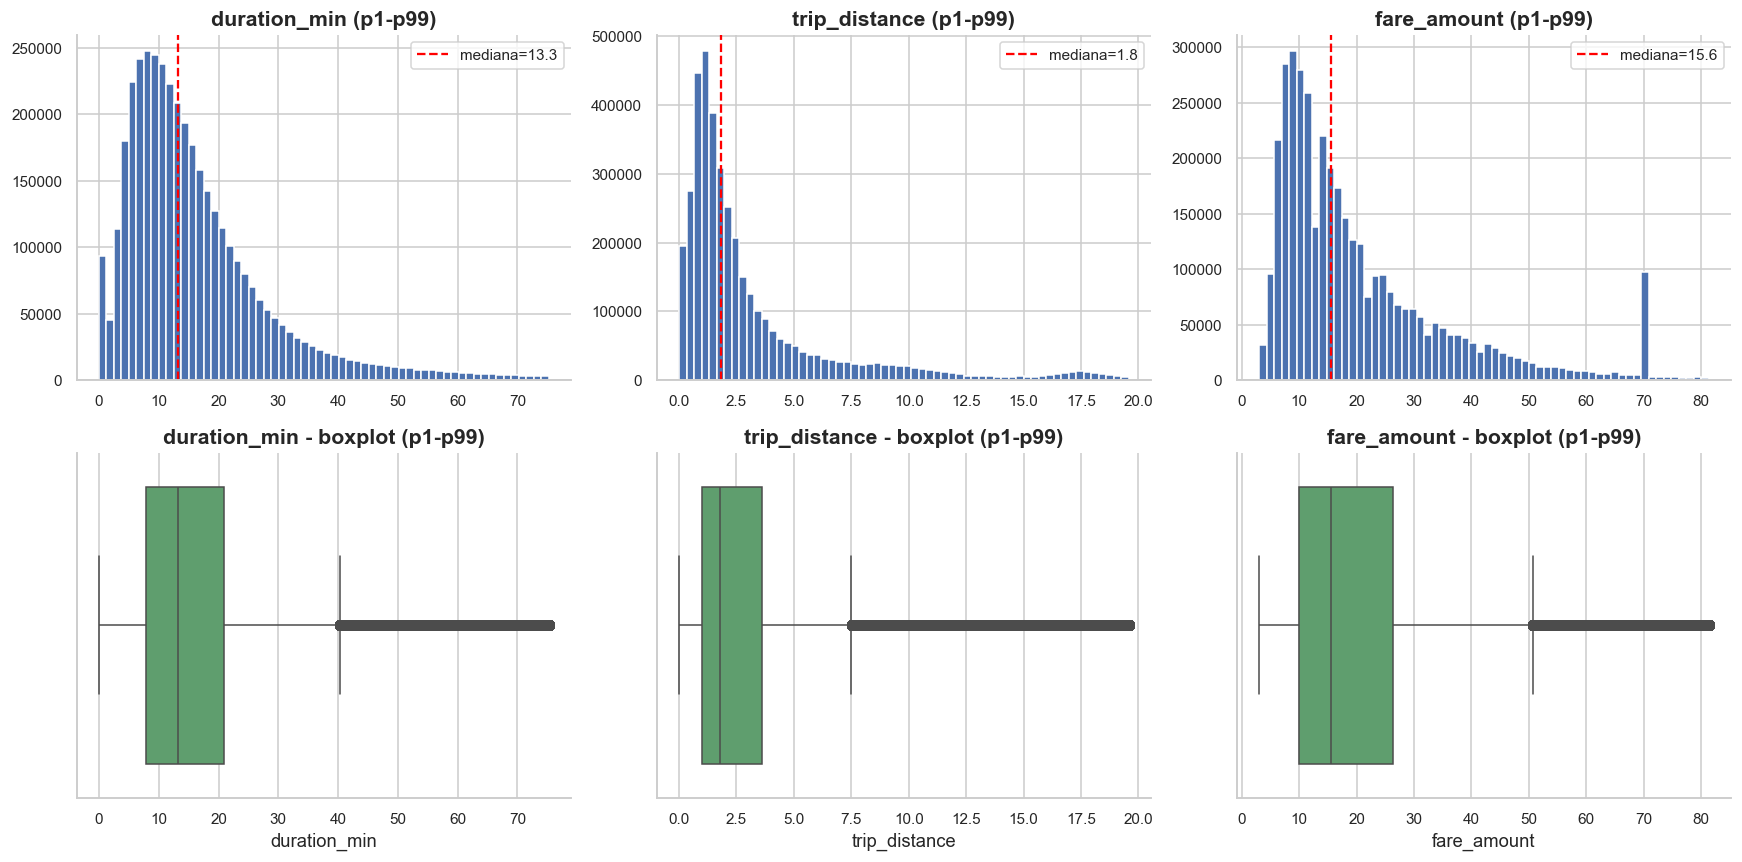

In [24]:
# Histograma (forma) + boxplot (cuartiles/outliers) por variable numérica clave.
# Recorte visual a p1-p99 para que la distribución central sea legible.

vis_cols = ['duration_min','trip_distance','fare_amount']
fig, ax = plt.subplots(2, 3, figsize=(16, 8))
for j, c in enumerate(vis_cols):
    s = df[c]
    s_clip = s[(s >= s.quantile(.01)) & (s <= s.quantile(.99))]
    ax[0, j].hist(s_clip, bins=60, color='#4C72B0', edgecolor='white')
    ax[0, j].axvline(s.median(), color='red', ls='--', label=f'mediana={s.median():.1f}')
    ax[0, j].set_title(f'{c} (p1-p99)'); ax[0, j].legend()
    sns.boxplot(x=s_clip, ax=ax[1, j], color='#55A868')
    ax[1, j].set_title(f'{c} - boxplot (p1-p99)')
plt.tight_layout(); plt.show()

**Interpretación.** Las tres variables tienen **distribución asimétrica a derecha** (sesgo positivo): la mayoría de los viajes son cortos/baratos y hay una cola larga de viajes largos. La mediana (línea roja) queda muy por debajo de la cola, confirmando por qué la media no es representativa.

### 2.2 Nivel 1 (simple) — Distribución de variables categóricas

**Concepto.** Para variables **categóricas** el gráfico apropiado (Clase 2) es el de **barras**: cuenta cuántos viajes caen en cada categoría. Lo aplicamos a medio de pago, tipo de tarifa y proveedor.

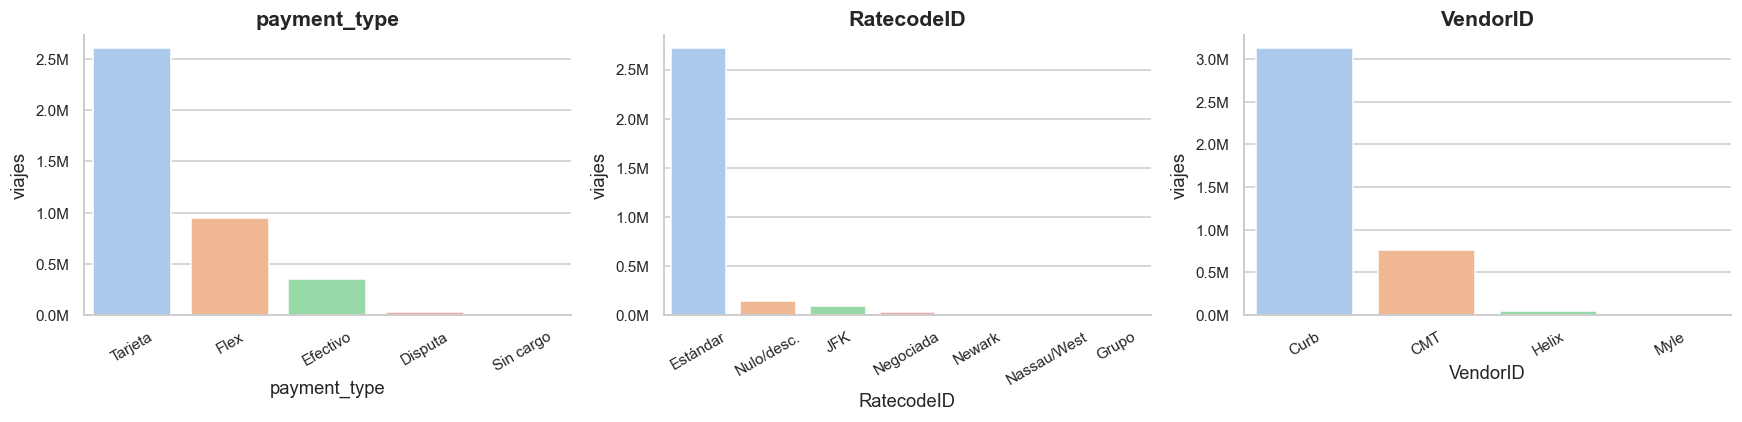

In [25]:
# Gráficos de barras (Clase 2) para 3 categóricas, con etiquetas legibles.

import matplotlib.ticker as mtick
mapas = {
    'payment_type': {0:'Flex',1:'Tarjeta',2:'Efectivo',3:'Sin cargo',4:'Disputa',5:'Desc.',6:'Anulado'},
    'RatecodeID':   {1:'Estándar',2:'JFK',3:'Newark',4:'Nassau/West',5:'Negociada',6:'Grupo',99:'Nulo/desc.'},
    'VendorID':     {1:'CMT',2:'Curb',6:'Myle',7:'Helix'},
}
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for j, c in enumerate(mapas):
    vc = df[c].map(mapas[c]).value_counts()
    sns.barplot(x=vc.index, y=vc.values, hue=vc.index, ax=ax[j], palette='pastel', legend=False)
    ax[j].set_title(c); ax[j].set_ylabel('viajes')
    ax[j].tick_params(axis='x', rotation=30)
    ax[j].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M'))
plt.tight_layout(); plt.show()

**Interpretación.** Predomina el pago con **tarjeta (66%)**, seguido de Flex Fare (24%) y efectivo (9%). En tarifa, casi todo es **rate estándar**; el proveedor **Curb (VendorID=2) concentra ~79%** de los viajes. Son variables muy desbalanceadas, dato a tener en cuenta si se usaran como features categóricas.

### 2.3 Nivel 2 — Patrones temporales

**Concepto.** Subimos un escalón: introducimos el **tiempo**. Una fecha tiene doble naturaleza (Clase 1): la usamos para *agrupar* (viajes por hora) y para detectar *patrones*. Combinamos un gráfico de barras por hora con un **mapa de calor** (Clase 2) hora × día de semana, que comprime dos dimensiones temporales en una sola imagen.

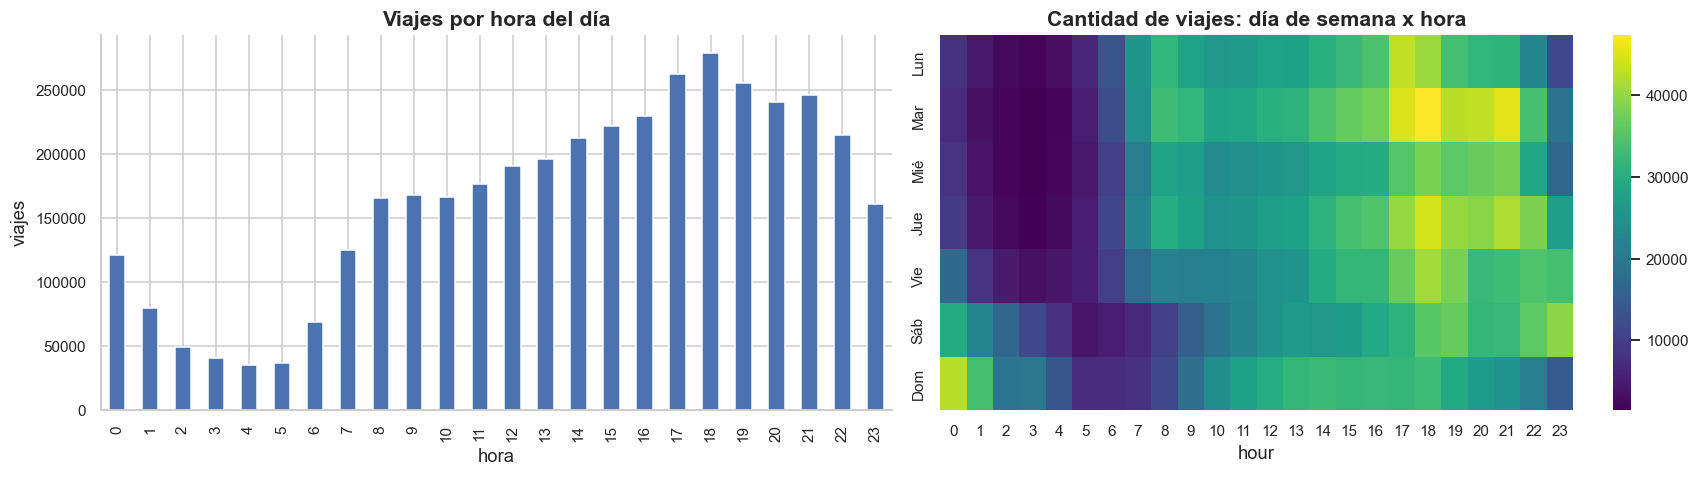

In [26]:
# Derivamos hora y día de semana; barras por hora + heatmap hora x día (Clase 2).

df['hour'] = df['tpep_pickup_datetime'].dt.hour
df['dow']  = df['tpep_pickup_datetime'].dt.dayofweek  # 0=Lunes
dias = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']
fig, ax = plt.subplots(1, 2, figsize=(16, 4.5))
df.groupby('hour').size().plot(kind='bar', ax=ax[0], color='#4C72B0')
ax[0].set_title('Viajes por hora del día'); ax[0].set_xlabel('hora'); ax[0].set_ylabel('viajes')
piv = df.pivot_table(index='dow', columns='hour', values='duration_min', aggfunc='size')
piv.index = dias
sns.heatmap(piv, cmap='viridis', ax=ax[1])
ax[1].set_title('Cantidad de viajes: día de semana x hora')
plt.tight_layout(); plt.show()

**Interpretación.** La demanda tiene un patrón diario marcado: **mínimo a las ~4 a.m.** y **pico a las ~18 h** (salida laboral). El heatmap muestra además el pico nocturno de los fines de semana (viernes/sábado de madrugada). La **hora** y el **día de semana** son, por lo tanto, candidatos como features: el horario condiciona el tipo de viaje (tráfico, salidas nocturnas, fines de semana) y puede asociarse a cuánta propina se deja.

### 2.4 Nivel 3 — Correlaciones entre numéricas: el caso de la estadística robusta

**Concepto.** Ahora medimos **relaciones** entre numéricas. La Clase 2 ofrece tres correlaciones: **Pearson** (lineal, NO robusta, sensible a outliers), **Spearman** (rangos, monótona, robusta) y **Kendall** (concordancia de pares, robusta). Este es el experimento que **justifica todo el criterio robusto** del trabajo: vamos a ver a Pearson fallar y a las robustas acertar.

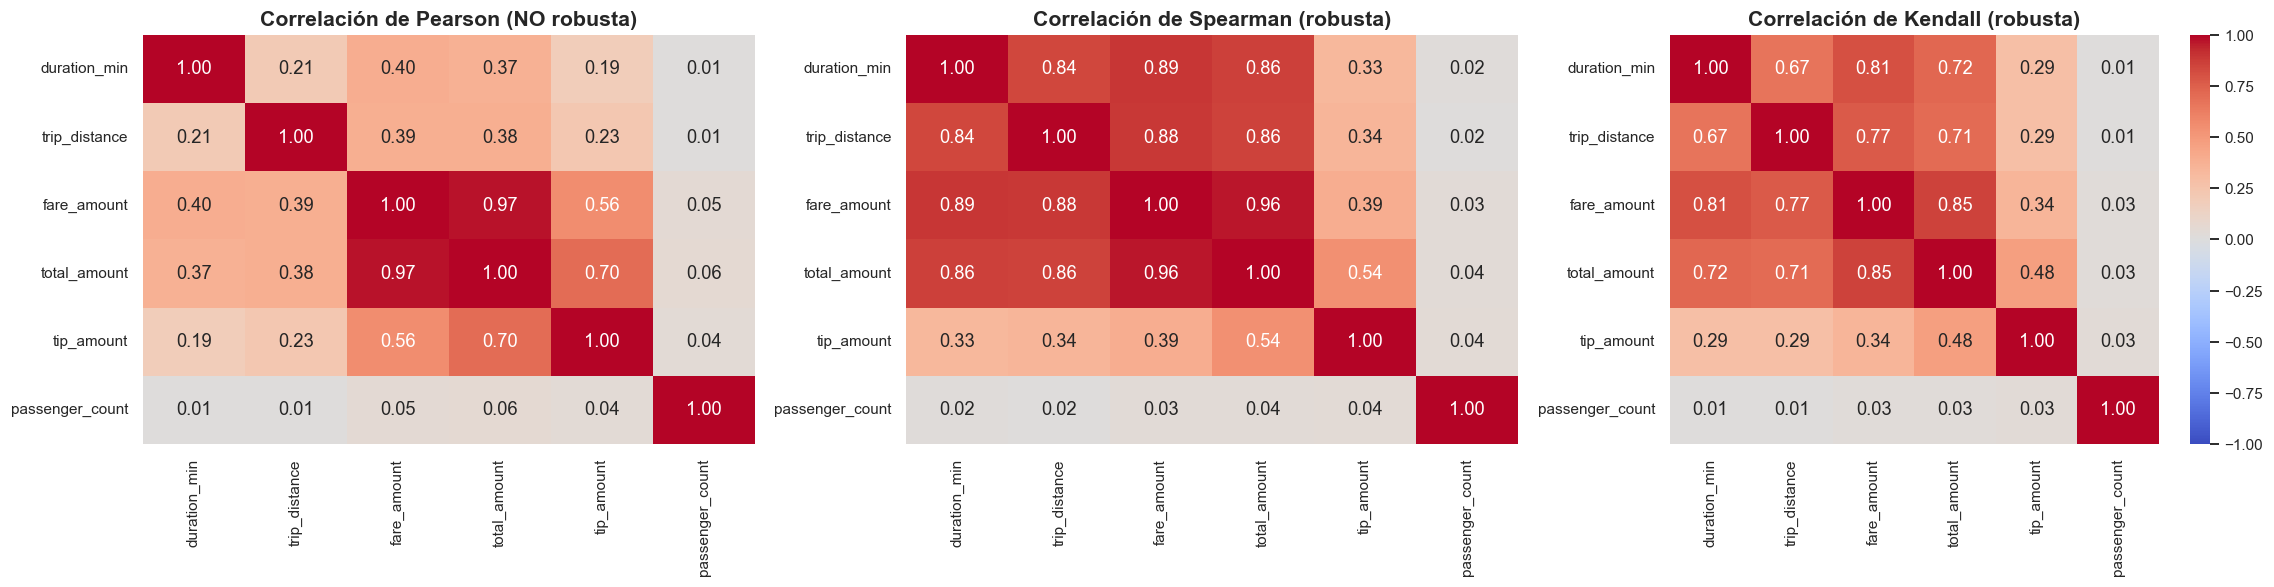

In [27]:
# Tres matrices de correlación lado a lado: Pearson vs Spearman vs Kendall (Clase 2),
# sobre una muestra (200k) para que el cálculo y el gráfico sean ágiles.

corr_cols = ['duration_min','trip_distance','fare_amount','total_amount','tip_amount','passenger_count']
samp = df[corr_cols].dropna().sample(200_000, random_state=0)
metodos = [('pearson','Pearson (NO robusta)'), ('spearman','Spearman (robusta)'), ('kendall','Kendall (robusta)')]
fig, ax = plt.subplots(1, 3, figsize=(21, 5.5))
for j, (m, titulo) in enumerate(metodos):
    sns.heatmap(samp.corr(method=m), annot=True, fmt='.2f', cmap='coolwarm',
                center=0, vmin=-1, vmax=1, ax=ax[j], cbar=(j == 2))
    ax[j].set_title(f'Correlación de {titulo}')
plt.tight_layout(); plt.show()

**Interpretación (caso de estadística robusta).** La **Pearson** entre `duration_min` y `trip_distance` da prácticamente **0** sobre los datos crudos, lo cual es absurdo (a más distancia, más duración). El culpable son los outliers extremos (distancias de cientos de miles de millas): Pearson asume relación lineal y es muy sensible a valores extremos.

Las dos medidas **robustas** vistas en clase revelan la relación real:

- **Spearman** (correlación de rangos, detecta relación monótona): **0,79** duración–distancia y **0,85** duración–tarifa.
- **Kendall** (concordancia de pares, también robusta): **0,63** duración–distancia y **0,72** duración–tarifa.

Kendall suele dar valores absolutos menores que Spearman para la misma asociación (compara pares concordantes/discordantes en vez de correlacionar rangos), pero ambas cuentan la misma historia: la asociación es **fuerte y positiva**, y Pearson la ocultaba por completo. Ante colas pesadas, conviene apoyarse en medidas robustas.

Otro hallazgo con implicancia directa para nuestro target: `total_amount` **incluye la propina dentro de su suma** (total = tarifa + propina + peajes + recargos). Usarlo para predecir `tip_amount` sería **fuga de información** pura (el target está metido en el feature). Por eso nos quedamos con `fare_amount` —la tarifa sin la propina— como predictor, y descartamos `total_amount`.

### 2.5 Nivel 4 (incisivo) — Relación numérica × categórica: violin plots

**Concepto.** Cruzamos una numérica (duración) con una categórica (tipo de tarifa, franja horaria). El **violin plot** (Clase 2) es más incisivo que un boxplot: es un boxplot **+** la densidad (KDE), así que muestra la *forma* completa por categoría, no solo los cuartiles.

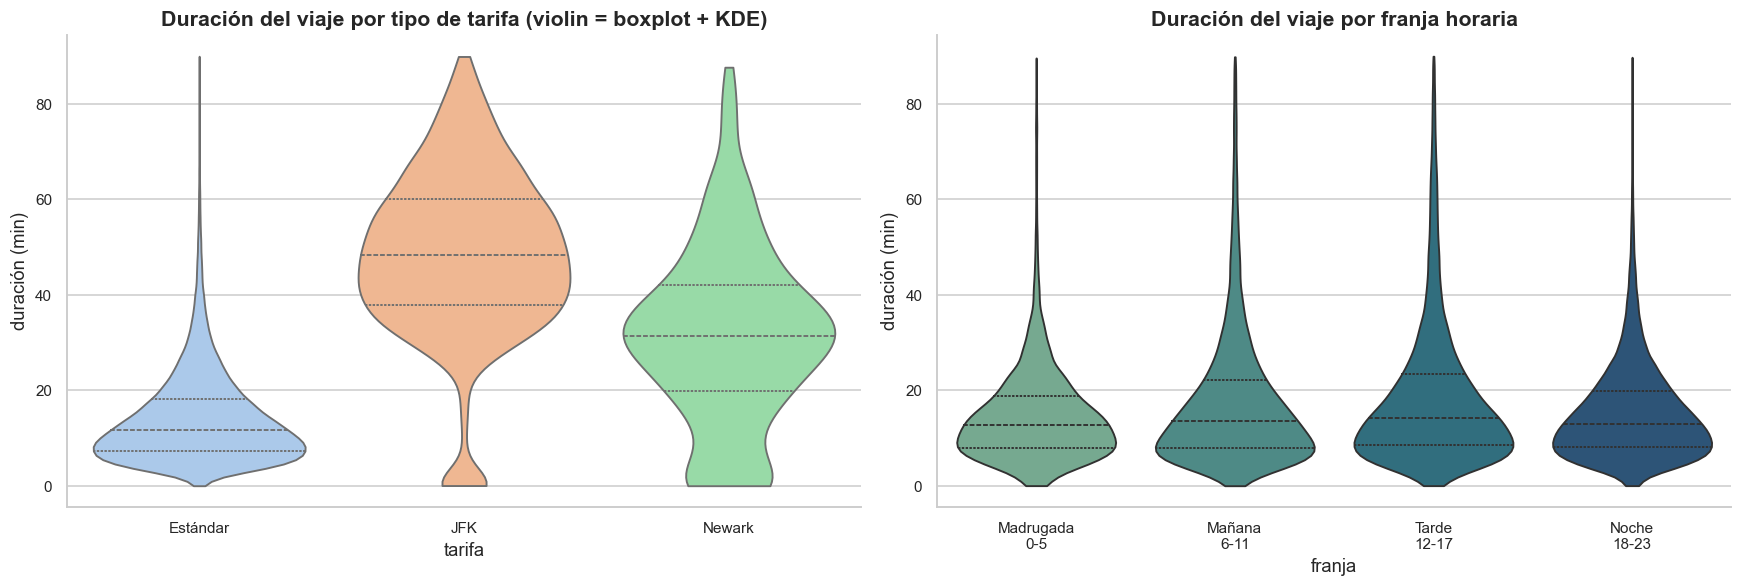

In [28]:
# Violin plots (boxplot + KDE, Clase 2): duración por tipo de tarifa y por franja horaria.

# Violin plots: duración según tipo de tarifa y según franja horaria
sub = df[(df['duration_min'] > 0) & (df['duration_min'] <= 90)].copy()
sub['tarifa'] = sub['RatecodeID'].map({1:'Estándar', 2:'JFK', 3:'Newark'})
sub['franja'] = pd.cut(sub['hour'], bins=[-1,5,11,17,23],
                       labels=['Madrugada\n0-5','Mañana\n6-11','Tarde\n12-17','Noche\n18-23'])

muestra = sub.dropna(subset=['tarifa']).sample(150_000, random_state=0)
fig, ax = plt.subplots(1, 2, figsize=(16, 5.5))
sns.violinplot(data=muestra, x='tarifa', y='duration_min', hue='tarifa', order=['Estándar','JFK','Newark'],
               palette='pastel', inner='quartile', cut=0, ax=ax[0], legend=False)
ax[0].set_title('Duración del viaje por tipo de tarifa (violin = boxplot + KDE)')
ax[0].set_ylabel('duración (min)')
sns.violinplot(data=sub.sample(150_000, random_state=0), x='franja', y='duration_min', hue='franja',
               palette='crest', inner='quartile', cut=0, ax=ax[1], legend=False)
ax[1].set_title('Duración del viaje por franja horaria')
ax[1].set_ylabel('duración (min)')
plt.tight_layout(); plt.show()

**Interpretación.** El violín izquierdo expone la mayor diferencia de todo el EDA: los viajes con tarifa **JFK tienen mediana de ~48 min** (distribución ancha y simétrica alrededor de la mediana) contra **~11,7 min de la tarifa estándar** (concentrada abajo, con cola superior). **Newark queda en el medio (~32 min)**. El tipo de tarifa codifica implícitamente el destino aeropuerto → es un predictor potente de la duración. (Contexto: **JFK** es el aeropuerto internacional, en Queens, a ~17 millas del centro de Manhattan; **Newark** está en New Jersey, cruzando el río Hudson — ambos con tarifas especiales de taxímetro, distintas de la tarifa estándar por reloj.)

Por franja horaria las **medianas son parecidas (12,4–14,2 min)** pero la *forma* cambia: la **tarde (12–17 h)** tiene el cuerpo más desplazado hacia arriba y cola más pesada (tráfico), mientras la madrugada se concentra en viajes cortos. Esto sugiere que la hora aporta señal sobre la duración más allá de la distancia — algo que un boxplot solo insinuaría y el violín hace visible.

**Profundizamos con evidencia cuantitativa.** El violín *sugiere* un efecto del tráfico; lo confirmamos con un número duro: la velocidad efectiva mediana por franja.

In [29]:
# Velocidad efectiva mediana por franja: traduce el efecto 'tráfico' a un número robusto.

# Evidencia cuantitativa del efecto tráfico: velocidad efectiva mediana por franja
vel = sub[(sub['duration_min'] > 1) & (sub['trip_distance'] > 0) & (sub['trip_distance'] <= 30)].copy()
vel['vel_mph'] = vel['trip_distance'] / (vel['duration_min']/60)
vel = vel[vel['vel_mph'] < 60]  # descarta velocidades físicamente imposibles
vel.groupby('franja', observed=True)['vel_mph'].median().round(1).rename('velocidad mediana (mph)').to_frame()

,velocidad mediana (mph)
franja,
Madrugada\n0-5,12.8
Mañana\n6-11,9.4
Tarde\n12-17,8.2
Noche\n18-23,10.0


**Interpretación.** La velocidad efectiva mediana cae de **12,8 mph en la madrugada a 8,2 mph en la tarde** (−36%): un mismo trayecto tarda ~50% más en hora pico. Esto confirma cuantitativamente lo que los violines insinuaban: la **hora del día aporta señal propia, independiente de la distancia**, y justifica las features horarias del modelo.

### 2.6 Nivel 5 (incisivo) — Relación multivariada: distancia × duración × tarifa

**Concepto.** El gráfico más rico hasta acá: **dos numéricas + una categórica** como color (Clase 2). Mostramos primero un *scatter* (intuitivo pero con *overplotting* por el volumen) y al lado un **hexbin con color logarítmico** —un scatter de densidad— para que la masa de datos **se vea** pese a los 3,9 M de puntos (consigna 7). Encima, la mediana por bin (estadística robusta) marca la tendencia.

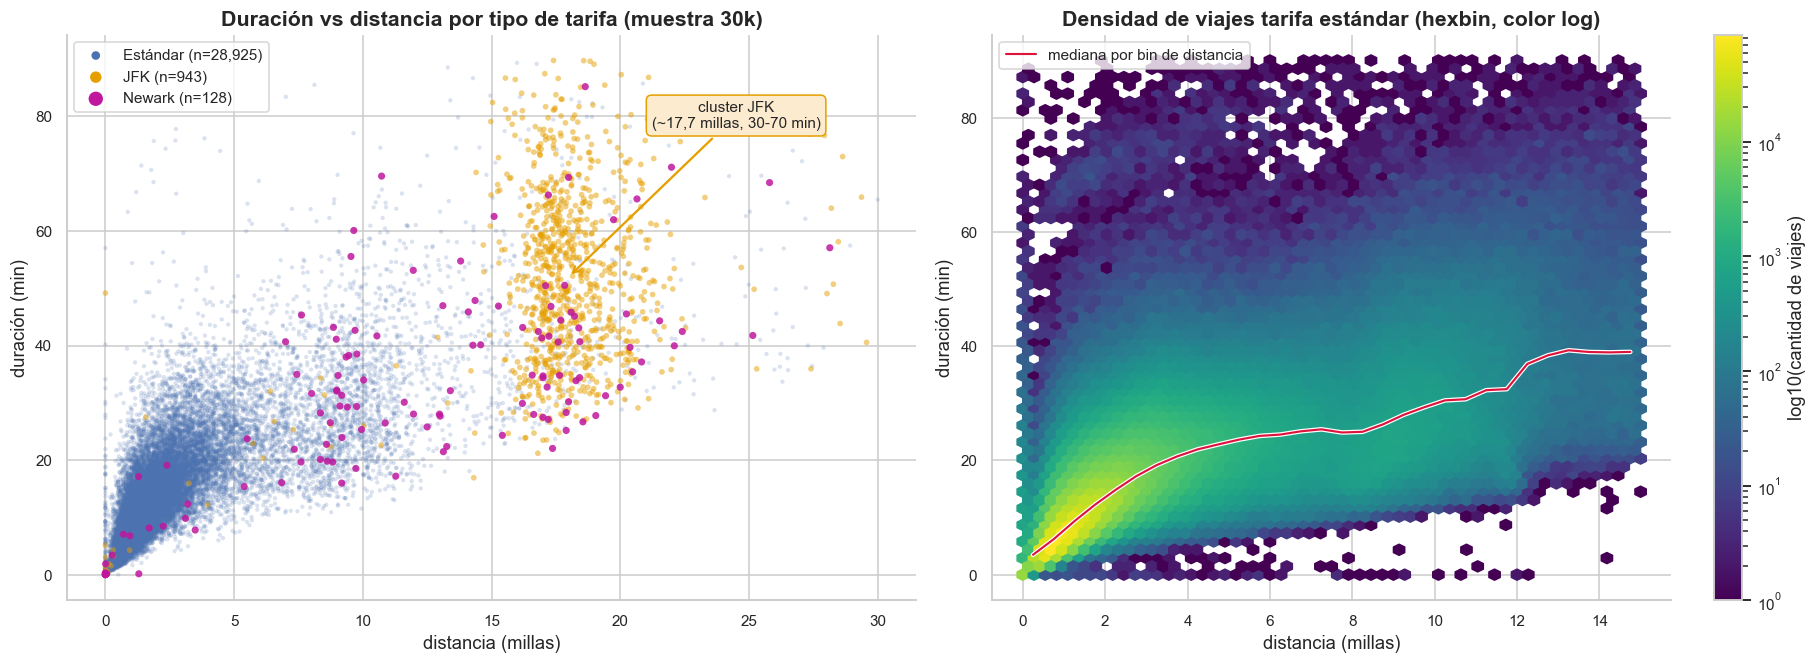

In [30]:
# Izq: scatter por capas (2 numéricas + tarifa como color). Der: hexbin densidad (log)
# + curva de mediana por bin de distancia (tendencia robusta). Resuelve el overplotting.

# Relación multivariada (slides clase 2): dos numéricas + una categórica como hue
fig, ax = plt.subplots(1, 2, figsize=(17, 6.2))

# Panel izquierdo: scatter por capas -> la clase mayoritaria de fondo y las minoritarias
# encima, con colores bien separados en tono (azul / naranja / magenta)
muestra2 = sub.dropna(subset=['tarifa']).sample(30_000, random_state=1)
muestra2 = muestra2[muestra2['trip_distance'] <= 30]
estilos = {  # color, alpha, tamaño: más opacas y grandes las clases con menos puntos
    'Estándar': ('#4C72B0', 0.20,  8),
    'JFK':      ('#E69F00', 0.50, 14),
    'Newark':   ('#C0179E', 0.85, 22),
}
for tarifa, (color, alpha, s) in estilos.items():
    g = muestra2[muestra2['tarifa'] == tarifa]
    ax[0].scatter(g['trip_distance'], g['duration_min'], c=color, alpha=alpha, s=s,
                  label=f'{tarifa} (n={len(g):,})', edgecolors='none')
ax[0].annotate('cluster JFK\n(~17,7 millas, 30-70 min)', xy=(18, 52), xytext=(24.5, 78),
               fontsize=10, ha='center',
               arrowprops=dict(arrowstyle='->', color='#E69F00', lw=1.5),
               bbox=dict(boxstyle='round,pad=0.35', fc='#FDEBD0', ec='#E69F00'))
ax[0].set_title('Duración vs distancia por tipo de tarifa (muestra 30k)')
ax[0].set_xlabel('distancia (millas)'); ax[0].set_ylabel('duración (min)')
leg = ax[0].legend(loc='upper left', markerscale=2)
for lh in leg.legend_handles: lh.set_alpha(1)

# Panel derecho: hexbin con color logarítmico -> densidad real, sin overplotting
est = sub[(sub['tarifa'] == 'Estándar') & (sub['trip_distance'] <= 15)]
hb = ax[1].hexbin(est['trip_distance'], est['duration_min'], gridsize=55, bins='log', cmap='viridis')
# tendencia central robusta: mediana de duración por bin de distancia
bins_d = pd.cut(est['trip_distance'], bins=np.arange(0, 15.5, 0.5))
med = est.groupby(bins_d, observed=True)['duration_min'].median()
centros = [iv.mid for iv in med.index]
ax[1].plot(centros, med.values, color='white', lw=3)
ax[1].plot(centros, med.values, color='crimson', lw=1.4, label='mediana por bin de distancia')
fig.colorbar(hb, ax=ax[1], label='log10(cantidad de viajes)')
ax[1].set_title('Densidad de viajes tarifa estándar (hexbin, color log)')
ax[1].set_xlabel('distancia (millas)'); ax[1].set_ylabel('duración (min)')
ax[1].legend(loc='upper left')
plt.tight_layout(); plt.show()

**Interpretación.** El scatter (izquierda) confirma la relación **monótona positiva** entre distancia y duración que Pearson no detectaba, y el **cluster JFK** queda anotado: viajes de ~17,7 millas con 30–70 min, la firma del trayecto Manhattan–aeropuerto.

El scatter, sin embargo, sufre **overplotting**: con tantos puntos superpuestos no se distingue dónde está la masa. El **hexbin con escala de color logarítmica** (derecha) lo resuelve y muestra que el grueso del negocio son viajes de **1–3 millas y 5–20 minutos**. La curva roja —**mediana de duración por bin de distancia**, otra aplicación de estadística robusta— crece de forma sostenida y casi lineal, pero la dispersión vertical alrededor de ella (un mismo trayecto puede tardar el doble según el tráfico) muestra cuánta información aportan la **hora** y la **zona** más allá de la distancia —features que después reutilizamos para modelar la propina.

### 2.7 Nivel 6 (incisivo) — Dimensión espacial: las zonas TLC

**Concepto.** Cierre de la escalada: la **geografía**. Las zonas son códigos; las cruzamos con la tabla oficial de la TLC para ponerles nombre y *borough*. Usamos **barras horizontales** (top de zonas), **barras 100% apiladas** (reparto por borough) y una **matriz Origen→Destino** como heatmap (tabla de contingencia, Clase 2) — el gráfico que sella el carácter Manhattan-céntrico del negocio.

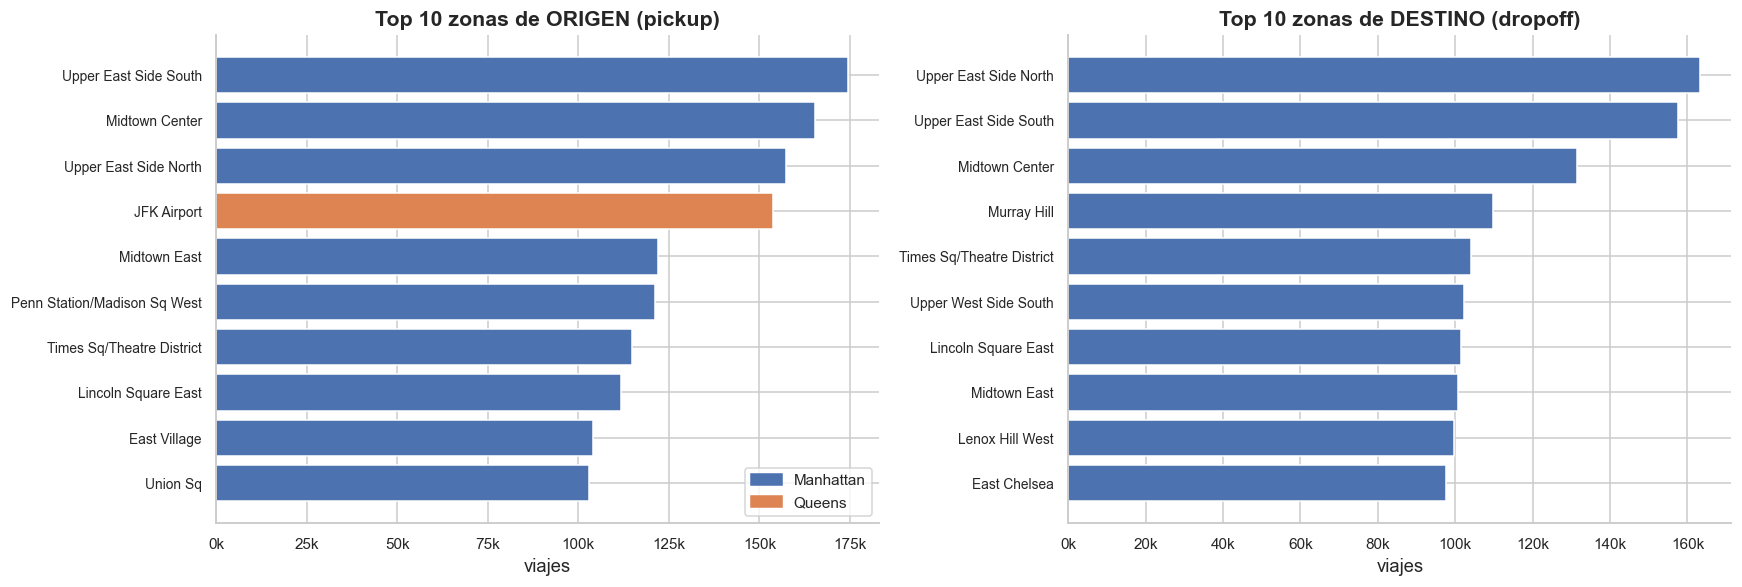

Pickups en Manhattan: 85.8%
Pickups en aeropuertos (JFK + LaGuardia): 6.3%
Cardinalidad de zonas: 261 orígenes / 260 destinos distintos


In [31]:
# Top-10 zonas de origen y destino con nombres reales (cruce con taxi_zone_lookup).

import matplotlib.ticker as mtick
import matplotlib.patches as mpatches

zonas = pd.read_csv(Path('dataset') / 'taxi_zone_lookup.csv').set_index('LocationID')
colores_boro = {'Manhattan':'#4C72B0', 'Queens':'#DD8452', 'Brooklyn':'#55A868', 'Bronx':'#C44E52'}

fig, ax = plt.subplots(1, 2, figsize=(16, 5.5))
for j, (col, titulo) in enumerate([('PULocationID','Top 10 zonas de ORIGEN (pickup)'),
                                   ('DOLocationID','Top 10 zonas de DESTINO (dropoff)')]):
    top = df[col].value_counts().head(10)
    nombres = top.index.map(zonas['Zone'])
    boros   = top.index.map(zonas['Borough'])
    ax[j].barh(range(len(top)), top.values, color=[colores_boro.get(b,'gray') for b in boros])
    ax[j].set_yticks(range(len(top))); ax[j].set_yticklabels(nombres, fontsize=9)
    ax[j].invert_yaxis()
    ax[j].set_title(titulo); ax[j].set_xlabel('viajes')
    ax[j].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'{x/1e3:.0f}k'))
ax[0].legend(handles=[mpatches.Patch(color=c, label=b) for b,c in colores_boro.items()
                      if b in ('Manhattan','Queens')], loc='lower right')
plt.tight_layout(); plt.show()

pu_boro = df['PULocationID'].map(zonas['Borough'])
print(f"Pickups en Manhattan: {100*pu_boro.eq('Manhattan').mean():.1f}%")
print(f"Pickups en aeropuertos (JFK + LaGuardia): {100*df['PULocationID'].isin([132,138]).mean():.1f}%")
print(f"Cardinalidad de zonas: {df['PULocationID'].nunique()} orígenes / {df['DOLocationID'].nunique()} destinos distintos")

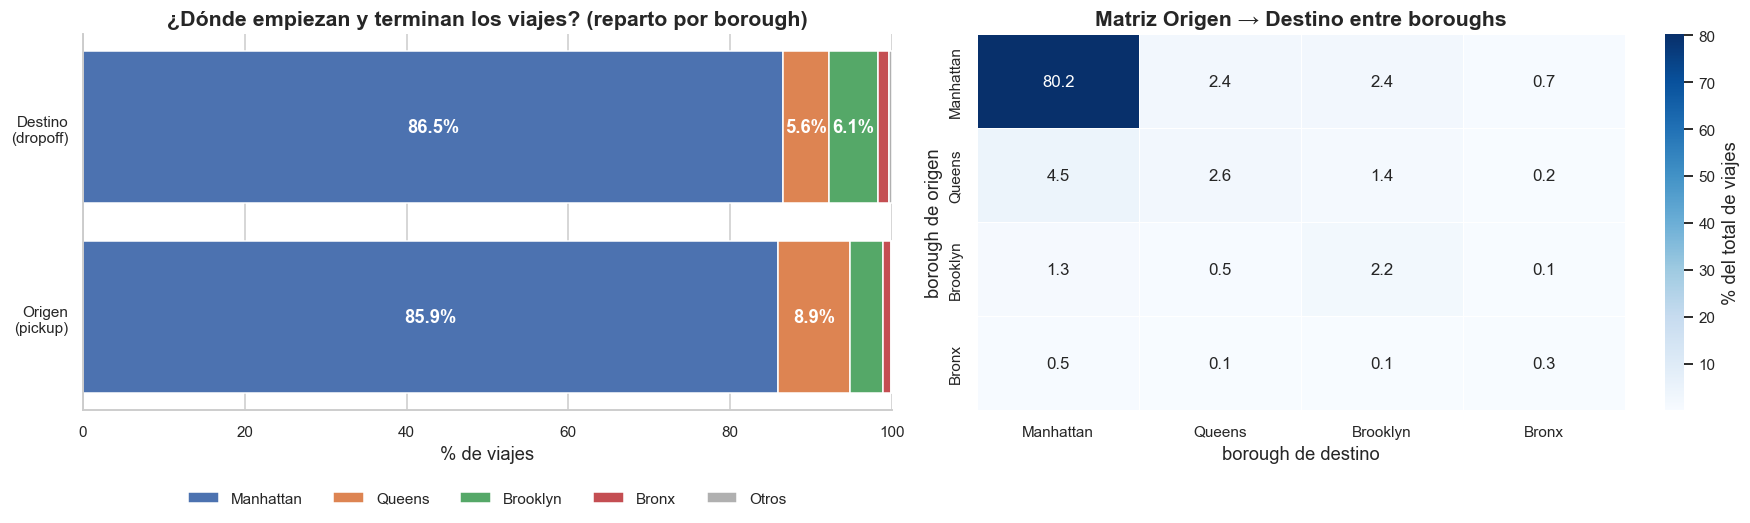

In [32]:
# Barras 100% apiladas por borough + matriz Origen->Destino (crosstab + heatmap, Clase 2).

# La evidencia visual del Manhattan-centrismo: proporciones por borough y matriz O-D
pu_b = df['PULocationID'].map(zonas['Borough'])
do_b = df['DOLocationID'].map(zonas['Borough'])
orden = ['Manhattan','Queens','Brooklyn','Bronx','Otros']
colores = {'Manhattan':'#4C72B0','Queens':'#DD8452','Brooklyn':'#55A868','Bronx':'#C44E52','Otros':'#B0B0B0'}

def shares(s):
    v = s.value_counts(normalize=True)*100
    v = v.reindex(orden[:-1]).fillna(0)
    v['Otros'] = 100 - v.sum()
    return v

fig, ax = plt.subplots(1, 2, figsize=(16.5, 5))

# Panel izquierdo: barras 100% apiladas -> el reparto completo en una sola mirada
filas = {'Origen\n(pickup)': shares(pu_b), 'Destino\n(dropoff)': shares(do_b)}
for yi, (lbl, v) in enumerate(filas.items()):
    izq = 0
    for b in orden:
        ax[0].barh(lbl, v[b], left=izq, color=colores[b], label=b if yi == 0 else None)
        if v[b] > 5:
            ax[0].text(izq + v[b]/2, yi, f'{v[b]:.1f}%', ha='center', va='center',
                       color='white', fontweight='bold', fontsize=12)
        izq += v[b]
ax[0].set_xlim(0, 100); ax[0].set_xlabel('% de viajes')
ax[0].set_title('¿Dónde empiezan y terminan los viajes? (reparto por borough)')
ax[0].legend(ncol=5, loc='upper center', bbox_to_anchor=(0.5, -0.18), frameon=False)

# Panel derecho: matriz Origen -> Destino entre boroughs (% del total de viajes)
od = (pd.crosstab(pu_b, do_b, normalize=True)*100).reindex(index=orden[:-1], columns=orden[:-1])
sns.heatmap(od, annot=True, fmt='.1f', cmap='Blues', linewidths=.5,
            annot_kws={'fontsize': 11}, cbar_kws={'label': '% del total de viajes'}, ax=ax[1])
ax[1].set_title('Matriz Origen → Destino entre boroughs')
ax[1].set_xlabel('borough de destino'); ax[1].set_ylabel('borough de origen')
plt.tight_layout(); plt.show()

**Interpretación.** El negocio del yellow cab es **abrumadoramente Manhattan-céntrico**, y los tres gráficos lo evidencian en niveles distintos:

- Las **barras apiladas** muestran el reparto completo: **85,9% de los orígenes y 86,5% de los destinos** son Manhattan; Queens aporta el segundo bloque de orígenes (8,9%) casi enteramente por sus dos aeropuertos.
- La **matriz Origen → Destino** lo sella: el **80,2% de *todos* los viajes empieza y termina dentro de Manhattan**. El segundo flujo es Queens → Manhattan (4,5%) — la vuelta del aeropuerto a la ciudad — y los flujos que no tocan Manhattan son marginales (Brooklyn → Brooklyn, 2,2%).
- El **top-10 por zona** pone nombres: Upper East Side, Midtown y los nodos de transporte (Penn Station, Times Sq) encabezan, con **JFK como 4º origen (3,9%)** pero ausente de los destinos top — el yellow cab domina la *salida* del aeropuerto más que la llegada.

Para el modelo, esto confirma a la zona como feature valiosa pero plantea un desafío: con **~260 valores distintos** y fuerte concentración, las zonas tienen **alta cardinalidad** → no conviene one-hot puro; en la etapa de *feature engineering* (Azul) convendrá *frequency/target encoding* o agrupar por borough.

---
# 3. Planteo del problema de ML supervisado

**De qué se trata esta sección.** Con el dataset ya comprendido, formalizamos la pregunta de negocio como un **problema de aprendizaje supervisado** (Clases 1 y 4): elegimos el **target**, decidimos si es **regresión o clasificación** y definimos el **universo** de datos sobre el que tiene sentido entrenar.

## 3. Planteo del problema de ML supervisado

### 3.1 Definición del problema

- **Target:** `tip_amount` (propina en USD). Variable numérica continua nativa del dataset.
- **Tipo de problema:** regresión supervisada.
- **Objetivo:** predecir el monto de propina que dejará el pasajero en viajes pagados con tarjeta.
- **Justificación:** problema realista para analizar ingresos adicionales y comportamiento de pasajeros. La propina suele decidirse como porcentaje de la tarifa, no como monto fijo.
- **Alcance / universo:** el diccionario TLC indica que `tip_amount` se registra automáticamente solo en pagos con tarjeta; en efectivo figura como 0 (MNAR). Por eso el modelado se restringe a `payment_type == 1`.
- **Desafíos:** outliers (valores negativos o propinas muy altas), multicolinealidad entre variables de tarifa/distancia, y posibles patrones geográficos u horarios explotables como features.

### 3.2 Exploración visual del target (universo tarjeta)

**Concepto.** Antes de modelar conviene *mirar el target*: cómo se distribuye `tip_amount` en el universo válido (tarjeta), cuántos viajes no dejan propina y si hay outliers. Esto anticipa el tratamiento de la Sección 4.

> **Nota de coherencia con el criterio robusto:** en estos primeros gráficos del target usamos la media por simplicidad descriptiva; en el preprocesamiento (§4) y en el resto del trabajo seguimos priorizando medidas robustas.

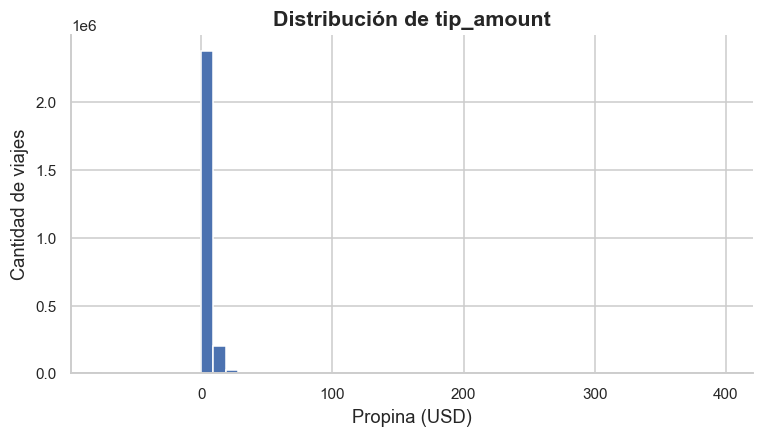

In [33]:
# Distribución de la propina en el universo tarjeta (histograma simple).

# Distribución de tip_amount

df_card = df[df["payment_type"] == 1].copy()

plt.figure(figsize=(8,4))
plt.hist(df_card["tip_amount"], bins=50)
plt.title("Distribución de tip_amount")
plt.xlabel("Propina (USD)")
plt.ylabel("Cantidad de viajes")
plt.show()


# En este gráfico, podemos observar que casi todas las propinas están concentradas muy cerca de 0, mientras que hay unas pocas que llegan hasta casi 400 USD.

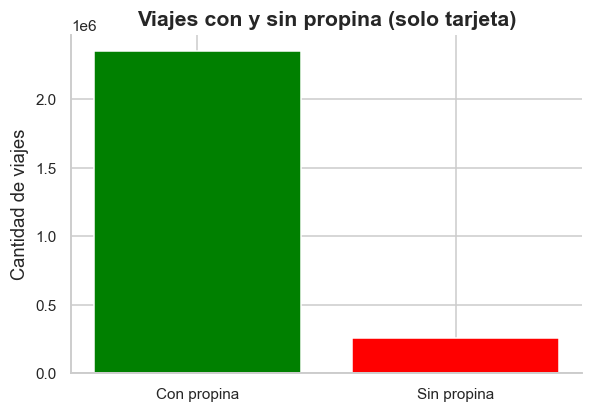

In [34]:
# Cuántos viajes dejan propina vs cuántos no (barras).

# Muestra de viajes pagados con tarjeta que dejaron propina vs que no dejaron

con_propina = (df_card["tip_amount"] > 0).sum()
sin_propina = (df_card["tip_amount"] == 0).sum()

plt.figure(figsize=(6, 4))
plt.bar(["Con propina", "Sin propina"], [con_propina, sin_propina],
        color=["green", "red"])
plt.title("Viajes con y sin propina (solo tarjeta)")
plt.ylabel("Cantidad de viajes")
plt.show()

# La mayoría de los viajes abonados con tarjeta registran una propina, aunque tambien existen viajes sin propina.

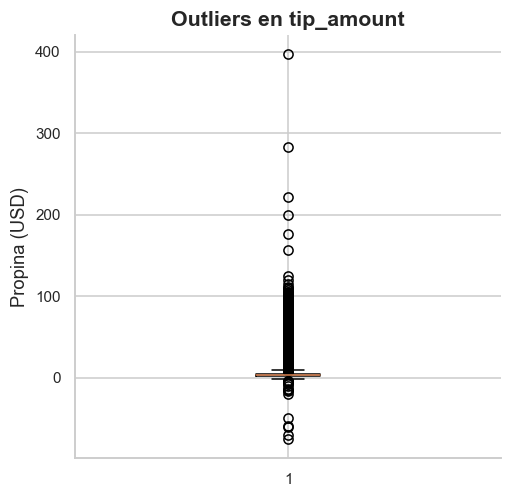

Valores negativos: 32
Valor máximo: $397.00


In [35]:
# Outliers de la propina (boxplot): se ven negativos y máximos extremos.

# Outliers en tip_amount

plt.figure(figsize=(5, 5))
plt.boxplot(df_card["tip_amount"].dropna())
plt.title("Outliers en tip_amount")
plt.ylabel("Propina (USD)")
plt.show()

print(f"Valores negativos: {(df_card['tip_amount'] < 0).sum()}")
print(f"Valor máximo: ${df_card['tip_amount'].max():.2f}")

# Se identifican outliers extremos en tip_amount, con propinas de monto elevado. Además, hay viajes con propina negativa, lo que podría indicar ajustes contables o errores en el registro de datos.


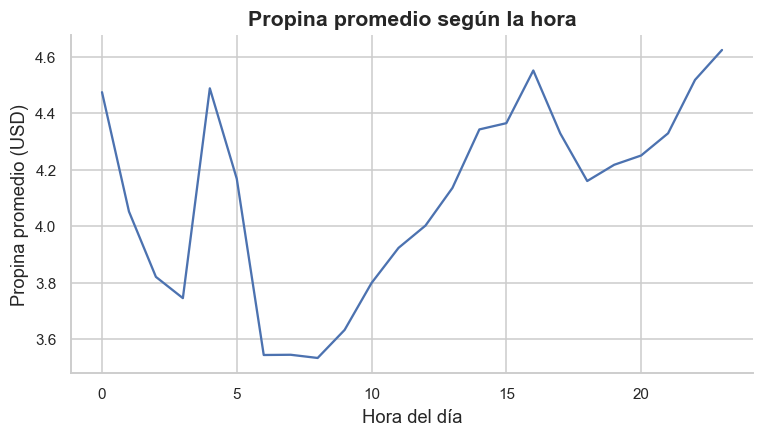

In [36]:
# Propina promedio por hora del día: primer indicio de patrón temporal en el target.

# Relación entre tip_amount y hora del día

df_card["pickup_hour"] = df_card["tpep_pickup_datetime"].dt.hour

df_card.groupby("pickup_hour")["tip_amount"].mean().plot(figsize=(8,4))
plt.title("Propina promedio según la hora")
plt.xlabel("Hora del día")
plt.ylabel("Propina promedio (USD)")
plt.show()

# La propina promedio es más baja en la mañana (~3,5 USD entre las 6 y 9 h, los viajes al trabajo)
# y sube a lo largo del día hasta el pico de la noche (~4,6 USD a las 22-23 h), con un repunte
# llamativo en la madrugada (0-4 h). La diferencia entre el mínimo y el máximo es de ~1 USD (un 31%)

**Conclusión de la Sección 3.** Queda definido el problema: **regresión de `tip_amount` (USD)** sobre **viajes pagados con tarjeta**. El target es muy asimétrico, con ceros y outliers que la Sección 4 va a tratar. Con esto, pasamos a preparar los datos.

---
# 4. Preprocesamiento y limpieza del dataset

**De qué se trata esta sección.** Acá ejecutamos el **flujo de preparación de datos** de las Clases 4 y 5, en el orden correcto y con una regla de oro para evitar trampas:

> ⚠️ **Primero el *split*, después transformar (Clase 5).** Todos los estadísticos (medianas, límites de outliers, parámetros de escalado) se **calculan solo en train** y se **aplican** al test. Si usáramos todo el dataset, el test "vería" información del train → *data leakage* y métricas engañosamente optimistas.

Orden: restringir universo y limpiar errores → *split* → faltantes → outliers. (El escalado, por pertenecer al armado final de la matriz, lo hacemos en la Sección 5.)

### 4.1 Filtrado a pagos con tarjeta y limpieza de inconsistencias

Primero restringimos el dataset al **universo válido para el target** (tarjeta) y eliminamos lo **físicamente imposible o inservible** para predecir la propina. Los outliers *plausibles* no se borran acá: se winsorizan en 4.5.

In [37]:
# Restringimos a tarjeta (universo del target) y eliminamos registros IMPOSIBLES
# (data cleaning, Clase 4). OJO: acá NO tocamos outliers plausibles, solo errores.

# Universo de análisis: SOLO pagos con tarjeta (payment_type == 1).
# Motivo (ver sección 3): la propina en efectivo no se registra (MNAR); incluir efectivo
# entrenaría un proxy del medio de pago, no la conducta de propina.
df_card = df[df['payment_type'] == 1].copy()
n0 = len(df)
print(f'Viajes totales:      {n0:,}')
print(f'Viajes con tarjeta:  {len(df_card):,}  ({100*len(df_card)/n0:.1f}% del dataset)\n')

# Limpieza de registros imposibles / inservibles para el target tip_amount.
reglas = [
    ('duración en (0, 180] min',          (df_card['duration_min'] > 0) & (df_card['duration_min'] <= 180)),
    ('distancia en (0, 100] millas',      (df_card['trip_distance'] > 0) & (df_card['trip_distance'] <= 100)),
    ('fare >= 2.50 (tarifa base mínima)',  df_card['fare_amount'] >= 2.50),
    ('tip_amount >= 0',                    df_card['tip_amount'] >= 0),
    ('pickup en marzo 2026',               df_card['tpep_pickup_datetime'].between('2026-03-01','2026-03-31 23:59:59')),
]
n1 = len(df_card)
for nombre, cond in reglas:
    antes = len(df_card)
    df_card = df_card[cond.reindex(df_card.index).fillna(False)]
    print(f'{nombre:36s} -> elimina {antes-len(df_card):>8,} filas')
print('-'*64)
print(f'Filas finales: {len(df_card):,}  ({100*len(df_card)/n1:.1f}% del universo tarjeta)')

Viajes totales:      3,952,451
Viajes con tarjeta:  2,608,830  (66.0% del dataset)



duración en (0, 180] min             -> elimina   43,410 filas
distancia en (0, 100] millas         -> elimina   19,572 filas
fare >= 2.50 (tarifa base mínima)    -> elimina      136 filas
tip_amount >= 0                      -> elimina        0 filas


pickup en marzo 2026                 -> elimina       15 filas
----------------------------------------------------------------
Filas finales: 2,545,697  (97.6% del universo tarjeta)


#### Filtros físicos adicionales (coherencia cinemática y tarifaria)

Sumamos dos reglas de la literatura de limpieza del dataset TLC, que descartan registros **corruptos** sin tocar los outliers plausibles (esos se winsorizan en 4.5):

- **(a) Velocidad imposible:** descartamos viajes con velocidad media `distancia / duración > 100 mph`. En una ciudad crónicamente congestionada es físicamente imposible → delata un error de GPS o de reloj a bordo.
- **(b) Coherencia tarifa–distancia (solo tarifa estándar):** para `RatecodeID == 1` el taxímetro acumula ~US$2,50 por milla; si la tarifa cobrada es menor que `2,50 × distancia`, la distancia reportada está corrupta (error de GPS). **El filtro se desactiva para tarifas planas o negociadas** (JFK=2, Newark=3, negociada=5, etc.), donde el precio *no* depende de la distancia y forzar esta relación eliminaría datos válidos.

In [38]:
# Dos filtros físicos extra (coherencia cinemática y tarifa-distancia) + chequeo de
# duplicados (data cleaning, Clase 4). Descartan registros corruptos, no outliers válidos.

# Filtros físicos adicionales (literatura de limpieza del dataset TLC)
# (a) Velocidad imposible: ningún viaje urbano sostiene > 100 mph promedio.
n_prev = len(df_card)
vel_mph = df_card['trip_distance'] / (df_card['duration_min'] / 60)   # millas por hora
df_card = df_card[vel_mph <= 100]
print(f'(a) velocidad media > 100 mph                 -> elimina {n_prev-len(df_card):>8,} filas')

# (b) Coherencia tarifa-distancia SOLO para tarifa estándar (RatecodeID == 1).
#     Las tarifas PLANAS/negociadas (JFK=2, Newark=3, negociada=5...) NO siguen
#     esta relación, por eso quedan EXCLUIDAS del filtro.
n_prev = len(df_card)
es_estandar  = df_card['RatecodeID'] == 1
incoherente  = es_estandar & (df_card['fare_amount'] < 2.50 * df_card['trip_distance'])
df_card = df_card[~incoherente]
print(f'(b) tarifa estándar incoherente con distancia -> elimina {n_prev-len(df_card):>8,} filas')
print('-'*64)
print(f'Filas finales tras filtros físicos: {len(df_card):,}')

# Chequeo de duplicados (data cleaning, Clase 4): no hay viajes repetidos.
print(f'\nFilas 100% duplicadas: {df_card.duplicated().sum():,}')


(a) velocidad media > 100 mph                 -> elimina      354 filas
(b) tarifa estándar incoherente con distancia -> elimina       68 filas
----------------------------------------------------------------
Filas finales tras filtros físicos: 2,545,275



Filas 100% duplicadas: 0


### 4.2 Definición del target: `tip_amount`

El target es la propina en dólares (`tip_amount`), una columna nativa del dataset: no requiere derivación ni transformación. Solo verificamos su distribución en el universo de tarjeta antes de seguir.

In [39]:
# El target es nativo (tip_amount en USD); solo verificamos su distribución post-filtro.

# Target = tip_amount (propina en USD). No se deriva: es una columna nativa del dataset.
print('Distribución de tip_amount (propina en USD, universo tarjeta):')

print(df_card['tip_amount'].describe(percentiles=[.25, .5, .75, .9, .99]).round(2))
print(f"\nViajes con propina > 0: {(df_card['tip_amount'] > 0).mean()*100:.1f}%  "
      f"(en tarjeta la propina sí se registra)")


Distribución de tip_amount (propina en USD, universo tarjeta):
count    2545275.00
mean           4.14
std            4.03
min            0.00
25%            2.00
50%            3.20
75%            4.83
90%            8.11
99%           18.98
max          222.00
Name: tip_amount, dtype: float64

Viajes con propina > 0: 90.2%  (en tarjeta la propina sí se registra)


### 4.3 Split train / test (antes de transformar)

> **Por qué split primero.** Si imputáramos o escaláramos usando estadísticos de *todo* el dataset, el test 'vería' información del train (data leakage). Criterio de la materia (Clase 5): **calcular medianas, límites de outliers y parámetros de escalado SOLO con el train**, y aplicarlos al test.

In [40]:
# Split 80/20 (Clase 4) ANTES de transformar. Excluimos total_amount como feature
# porque incluye la propina -> sería fuga de información directa sobre el target.

from sklearn.model_selection import train_test_split

features = ['trip_distance','duration_min','fare_amount','PULocationID','DOLocationID',
            'passenger_count','hour','dow','RatecodeID','VendorID']
target = 'tip_amount'

X = df_card[features].copy()
y = df_card[target].copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape[0]:,} filas | Test: {X_test.shape[0]:,} filas')
print(f'Features: {features}')
print(f'Target:   {target}  (excluido por leakage: total_amount, que contiene la propina)')


Train: 2,036,220 filas | Test: 509,055 filas
Features: ['trip_distance', 'duration_min', 'fare_amount', 'PULocationID', 'DOLocationID', 'passenger_count', 'hour', 'dow', 'RatecodeID', 'VendorID']
Target:   tip_amount  (excluido por leakage: total_amount, que contiene la propina)


### 4.4 Valores faltantes

En el dataset completo, 5 columnas tienen 23,93% de faltantes, y en 1.3 vimos que son **estructurales (MAR)**: faltan exactamente en los viajes Flex Fare (`payment_type == 0`). Como nuestro universo es **solo tarjeta** (`payment_type == 1`), esos faltantes quedan **fuera por construcción**. Lo verificamos antes de seguir, en lugar de imputar a ciegas.

In [41]:
# Verificamos que en el universo tarjeta NO quedan faltantes (vivían 100% en Flex Fare,
# que ya quedó afuera). Por eso NO imputamos: imputar a ciegas sería un error (Clase 4).

# Los faltantes estructurales vivían 100% en Flex Fare (payment_type==0), que ya
# quedó fuera del universo tarjeta. Verificamos que no queda ninguno por tratar.
nulos_train = X_train.isna().sum()
print('Faltantes por columna en el universo tarjeta (post-filtro):')
print(nulos_train[nulos_train > 0] if nulos_train.sum() else '  Sin faltantes: 0 en todas las columnas.')
print(f'\nTotal de NaN -> train: {int(X_train.isna().sum().sum())} | test: {int(X_test.isna().sum().sum())}')
# => No se requiere imputación. Tampoco agregamos bandera de faltante: sería
#    constante (todo 0) en este universo, una feature sin información.


Faltantes por columna en el universo tarjeta (post-filtro):
  Sin faltantes: 0 en todas las columnas.

Total de NaN -> train: 0 | test: 0


### 4.5 Tratamiento de outliers (winsorización por percentiles, Clase 4)

**Concepto.** Los errores imposibles ya se eliminaron (§4.1). A los **outliers plausibles** (viajes largos y caros, reales) no los borramos: los **acotamos** con **winsorización/capping** (Clase 4), que reemplaza los extremos por un percentil. Elegimos **p1–p99** (no IQR×1,5) porque en este universo el IQR es muy estrecho y borraría viajes de aeropuerto válidos —justo donde están las propinas altas que el modelo necesita aprender. Todos los límites se calculan **solo en train**.

In [42]:
# Winsorización por percentiles p1-p99 del TRAIN (capping, Clase 4) en features continuas,
# y cap de la cola superior extrema del target. Se aplica a train y test con límites de train.

# === Winsorización de features continuas (límites p1–p99 del TRAIN) ===
# Usamos percentiles en vez de IQR*1.5: en este universo el IQR recortaría los
# viajes largos/caros (aeropuertos), legítimos y donde están las propinas altas.
print('Winsorización de features (cap p1–p99, límites del train):')
cols_winsor = ['trip_distance', 'duration_min', 'fare_amount']
for c in cols_winsor:
    lo, hi = X_train[c].quantile(.01), X_train[c].quantile(.99)
    for split in (X_train, X_test):
        split[c] = split[c].clip(lower=max(lo, 0), upper=hi)
    print(f'  {c:14s} -> [{max(lo, 0):.2f}, {hi:.2f}]')

# Target: solo recortamos la cola superior extrema (errores tipo $397).
# NO usamos IQR: cliparía ~9% de propinas altas que son válidas (viajes caros).
y_hi = y_train.quantile(.995)
y_train = y_train.clip(lower=0, upper=y_hi)
y_test  = y_test.clip(lower=0, upper=y_hi)
print(f'\nTarget tip_amount -> [0.00, {y_hi:.2f}]  (cap p99.5 del train)')

# === (Opcional) Por qué no usamos log1p: comparación de asimetría ===
# Se mide sobre df_card (valores aún sin winsorizar). log1p simetriza más,
# pero cambia las unidades; winsorizar conserva los dólares/millas.
print('\nAsimetría (skew) — cuanto más cerca de 0, más simétrica:')
print(f"  {'variable':14s} {'cruda':>7s} {'winsor':>8s} {'log1p':>8s}")
for col in ['fare_amount', 'tip_amount', 'trip_distance']:
    s = df_card[col]
    lo, hi = s.quantile(.01), s.quantile(.99)
    print(f'  {col:14s} {s.skew():7.2f} {s.clip(lo, hi).skew():8.2f} {np.log1p(s).skew():8.2f}')


Winsorización de features (cap p1–p99, límites del train):
  trip_distance  -> [0.30, 20.09]
  duration_min   -> [2.15, 80.68]
  fare_amount    -> [4.40, 77.90]

Target tip_amount -> [0.00, 21.61]  (cap p99.5 del train)

Asimetría (skew) — cuanto más cerca de 0, más simétrica:
  variable         cruda   winsor    log1p


  fare_amount       3.20     1.98     0.74
  tip_amount        3.62     2.05    -0.19
  trip_distance     2.79     2.33     1.12


### 4.6 Resultado del preprocesamiento

In [43]:
# Estado del dataset tras limpieza+split+outliers, listo para feature engineering.

print('Dataset limpio y winsorizado, listo para feature engineering:')
print(f'  X_train: {X_train.shape}   y_train: {y_train.shape}')
print(f'  X_test:  {X_test.shape}    y_test:  {y_test.shape}')
print(f'  Target:  tip_amount (propina en USD) | universo: pagos con tarjeta')
print(f'  Features disponibles: {list(X_train.columns)}')
X_train.head()


Dataset limpio y winsorizado, listo para feature engineering:
  X_train: (2036220, 10)   y_train: (2036220,)
  X_test:  (509055, 10)    y_test:  (509055,)
  Target:  tip_amount (propina en USD) | universo: pagos con tarjeta
  Features disponibles: ['trip_distance', 'duration_min', 'fare_amount', 'PULocationID', 'DOLocationID', 'passenger_count', 'hour', 'dow', 'RatecodeID', 'VendorID']


,trip_distance,duration_min,fare_amount,PULocationID,DOLocationID,passenger_count,hour,dow,RatecodeID,VendorID
103344,1.92,12.850000,13.5,66,49,1.0,11,0,1.0,2
1924904,2.80,13.483333,16.3,142,75,2.0,14,4,1.0,1
2809771,2.53,21.416667,19.8,186,142,1.0,18,6,1.0,2
363419,3.60,23.000000,19.8,144,161,1.0,22,2,1.0,1
1605994,0.49,6.516667,7.2,186,90,1.0,15,1,1.0,2


**Conclusión de la Sección 4.** Tenemos un dataset **limpio, partido en train/test sin fugas y con outliers acotados**. Sobre esta base sólida construimos los features de la Sección 5.

---
# 5. Feature engineering

**De qué se trata esta sección.** Construimos la **matriz de features** definitiva (Clases 4 y 5): creamos variables nuevas que capturan señal latente, **discretizamos**, **codificamos** las categóricas según su cardinalidad, analizamos el balance y **escalamos**. Igual que en §4, todo lo que aprende parámetros se **ajusta en train y se aplica al test**.

In [44]:
# Partimos del split ya limpio y winsorizado (sin escalar todavía).

# Partimos del split original (sin escalar)
X_train_fe = X_train.copy()
X_test_fe  = X_test.copy()

print("Columnas disponibles:", list(X_train_fe.columns))
print(f"X_train_fe: {X_train_fe.shape}  |  X_test_fe: {X_test_fe.shape}")

Columnas disponibles: ['trip_distance', 'duration_min', 'fare_amount', 'PULocationID', 'DOLocationID', 'passenger_count', 'hour', 'dow', 'RatecodeID', 'VendorID']
X_train_fe: (2036220, 10)  |  X_test_fe: (509055, 10)


### 5.1 Creación de nuevas variables

Creamos cuatro nuevas variables a partir de las ya disponibles. Cada una captura información latente que el modelo no puede inferir directamente de las columnas originales por separado:

| Variable nueva | Fórmula / Fuente | Justificación |
|---|---|---|
| `speed_mph` | `trip_distance / (duration_min / 60)` | Proxy de congestión de tránsito; el EDA mostró que la velocidad cae 36 % en hora pico |
| `fare_per_mile` | `fare_amount / trip_distance` | Discrimina tarifa medida (≈ $3/mi) de tarifa plana (aeropuerto, negociada); la propina suele seguir un patrón distinto |
| `es_aeropuerto` | `RatecodeID ∈ {2, 3}` | El EDA mostró que los viajes JFK/Newark duran ~48 min vs ~12 min estándar y tienen una estructura de propina diferente |
| `es_hora_pico` | `hour ∈ {7,8,9,17,18,19}` | El heatmap temporal mostró congestión máxima en esas bandas horarias, correlacionada con la duración y la propina |

In [45]:
# Creamos 4 features (Clase 5): speed_mph y fare_per_mile (matemáticas A/B),
# es_aeropuerto y es_hora_pico (indicadores de dominio). fare_per_mile se imputa
# con la mediana del train para evitar fuga al dividir por distancias chicas.

# Velocidad efectiva: proxy de tránsito y tipo de viaje
X_train_fe['speed_mph'] = X_train_fe['trip_distance'] / (X_train_fe['duration_min'] / 60)
X_test_fe['speed_mph']  = X_test_fe['trip_distance']  / (X_test_fe['duration_min'] / 60)

# Tarifa por milla: discrimina tarifa medida vs tarifa plana (aeropuerto, negociada)
X_train_fe['fare_per_mile'] = X_train_fe['fare_amount'] / X_train_fe['trip_distance'].replace(0, np.nan)
X_test_fe['fare_per_mile']  = X_test_fe['fare_amount']  / X_test_fe['trip_distance'].replace(0, np.nan)
# Imputamos la mediana del train para evitar fuga de datos
_fare_median = X_train_fe['fare_per_mile'].median()
X_train_fe['fare_per_mile'] = X_train_fe['fare_per_mile'].fillna(_fare_median)
X_test_fe['fare_per_mile']  = X_test_fe['fare_per_mile'].fillna(_fare_median)

# Indicador de aeropuerto: JFK (RatecodeID=2) y Newark (3) son estructuralmente distintos
X_train_fe['es_aeropuerto'] = X_train_fe['RatecodeID'].isin([2, 3]).astype(int)
X_test_fe['es_aeropuerto']  = X_test_fe['RatecodeID'].isin([2, 3]).astype(int)

# Indicador de hora pico: congestión máxima en 7-9 AM y 17-19 hs
X_train_fe['es_hora_pico'] = X_train_fe['hour'].isin([7, 8, 9, 17, 18, 19]).astype(int)
X_test_fe['es_hora_pico']  = X_test_fe['hour'].isin([7, 8, 9, 17, 18, 19]).astype(int)

print("Nuevas variables creadas:", ['speed_mph', 'fare_per_mile', 'es_aeropuerto', 'es_hora_pico'])
print(X_train_fe[['speed_mph', 'fare_per_mile', 'es_aeropuerto', 'es_hora_pico']].describe().round(2))

Nuevas variables creadas: ['speed_mph', 'fare_per_mile', 'es_aeropuerto', 'es_hora_pico']


        speed_mph  fare_per_mile  es_aeropuerto  es_hora_pico
count  2036220.00     2036220.00     2036220.00    2036220.00
mean        10.59           8.36           0.03          0.32
std          5.81          10.04           0.18          0.47
min          0.22           0.82           0.00          0.00
25%          6.95           5.74           0.00          0.00
50%          9.14           7.34           0.00          0.00
75%         12.33           9.34           0.00          1.00
max         96.46         259.67           1.00          1.00


**Conclusión.** Cuatro variables nuevas, cada una **justificada por el EDA o el dominio** (consigna: crear features *justificando*): la velocidad y la tarifa-por-milla resumen el tipo de viaje; los indicadores de aeropuerto y hora pico marcan los contextos donde la duración y la propina cambian de régimen.

### 5.2 Discretización de una variable continua (Clase 5)

**Concepto.** La consigna pide aplicar **técnicas de conversión de variables: codificación y discretización**. La **discretización** (Clase 5) convierte una variable **continua** en **categórica**, agrupando en tramos. De los métodos de la Clase 5 (intervalos iguales, **cuantiles**, k-means, rango fijo) usamos **cuantiles**, que funciona bien con datos asimétricos como los nuestros. Los cortes se calculan **solo en train**.

Lo aplicamos a `fare_amount` para *validar* que separa el target (¿deja más propina quien paga tarifas más altas?). Lo mostramos como técnica; **no** lo incorporamos a la matriz final para no duplicar la señal continua de `fare_amount`, que preferimos conservar en dólares.

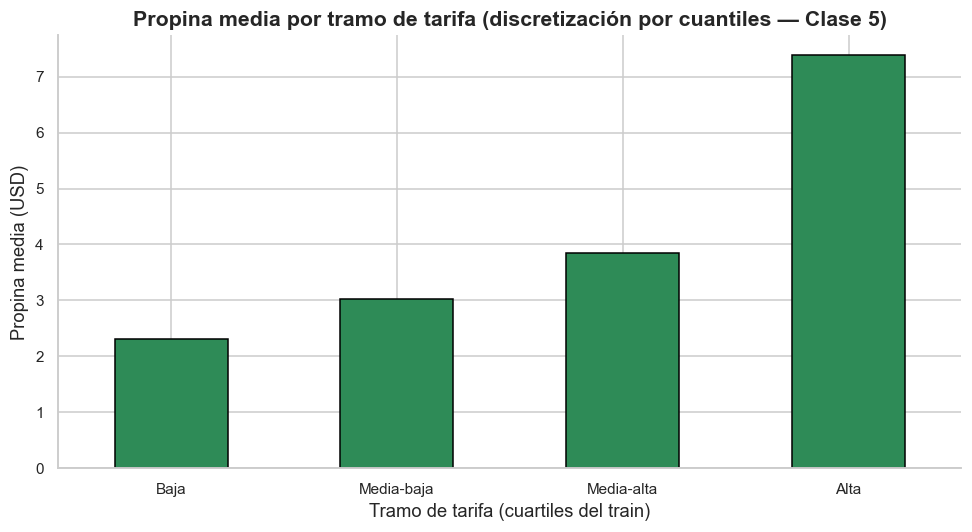

Baja          2.31
Media-baja    3.03
Media-alta    3.85
Alta          7.38
Name: tip_amount, dtype: float64


In [46]:
# Discretización por cuantiles (Clase 5): cortes calculados SOLO en train (sin fuga).
_bins_fare = X_train['fare_amount'].quantile([0, .25, .5, .75, 1.0]).values
_bins_fare[0], _bins_fare[-1] = -np.inf, np.inf   # bordes abiertos para cubrir el rango del test
_labels = ['Baja', 'Media-baja', 'Media-alta', 'Alta']
_fare_disc_train = pd.cut(X_train['fare_amount'], bins=_bins_fare, labels=_labels)

# Validación: propina media por tramo de tarifa (¿la discretización separa el target?)
_tip_by_bin = y_train.groupby(_fare_disc_train.values, observed=False).mean().reindex(_labels)

ax = _tip_by_bin.plot.bar(figsize=(9, 5), color='seagreen', edgecolor='black')
ax.set_title('Propina media por tramo de tarifa (discretización por cuantiles — Clase 5)')
ax.set_xlabel('Tramo de tarifa (cuartiles del train)'); ax.set_ylabel('Propina media (USD)')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()
print(_tip_by_bin.round(2))

**Conclusión del gráfico.** La propina media **crece monótonamente** del tramo "Baja" al "Alta": confirma que la tarifa es un predictor fuerte de la propina (coherente con que la gente propina como % de la tarifa). La discretización deja esto a la vista de forma muy legible, aunque para el modelo conservemos la versión continua.

### 5.3 Codificación cíclica de variables temporales (Clase 4)

**Concepto.** `hour` (0–23) y `dow` (0–6) son **cíclicas**: la hora 23 y la 0 están a un minuto, pero numéricamente parecen los extremos opuestos. La **codificación cíclica** (Clase 4) las proyecta sobre un círculo con **seno y coseno**, preservando esa continuidad. Reemplazamos cada variable por su par sin/cos.

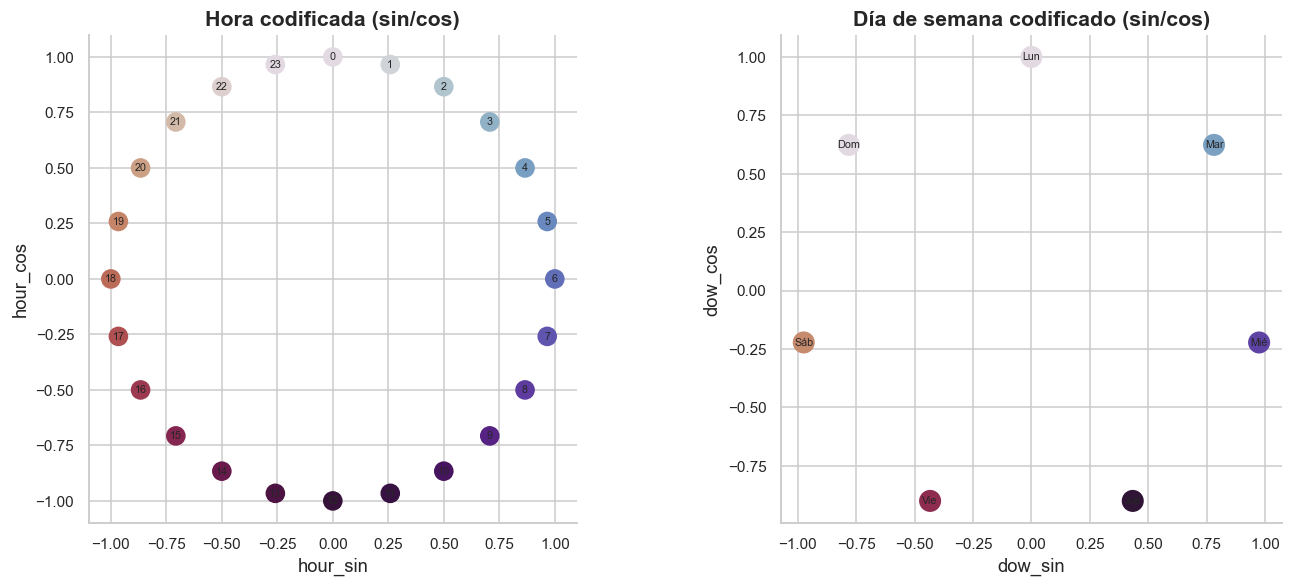

Variables cíclicas creadas: ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']


In [47]:
# Codificación cíclica (Clase 4): variable con período P -> (sin, cos).
# Usamos 'd' como variable de loop para NO pisar el DataFrame global 'df'.
for d in (X_train_fe, X_test_fe):
    d['hour_sin'] = np.sin(2 * np.pi * d['hour'] / 24)
    d['hour_cos'] = np.cos(2 * np.pi * d['hour'] / 24)
    d['dow_sin']  = np.sin(2 * np.pi * d['dow']  / 7)
    d['dow_cos']  = np.cos(2 * np.pi * d['dow']  / 7)

# Reemplazamos las columnas originales por su versión cíclica
X_train_fe = X_train_fe.drop(columns=['hour', 'dow'])
X_test_fe  = X_test_fe.drop(columns=['hour', 'dow'])

# Visualización: cada valor cae sobre un círculo unitario (la continuidad cíclica se ve).
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
_h = np.arange(24)
axes[0].scatter(np.sin(2*np.pi*_h/24), np.cos(2*np.pi*_h/24), c=_h, cmap='twilight', s=140)
for h in _h:
    axes[0].annotate(str(h), (np.sin(2*np.pi*h/24), np.cos(2*np.pi*h/24)),
                     ha='center', va='center', fontsize=7)
axes[0].set_title('Hora codificada (sin/cos)'); axes[0].set_aspect('equal')
axes[0].set_xlabel('hour_sin'); axes[0].set_ylabel('hour_cos')

_d = np.arange(7); dias = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']
axes[1].scatter(np.sin(2*np.pi*_d/7), np.cos(2*np.pi*_d/7), c=_d, cmap='twilight', s=180)
for i, nombre in enumerate(dias):
    axes[1].annotate(nombre, (np.sin(2*np.pi*i/7), np.cos(2*np.pi*i/7)),
                     ha='center', va='center', fontsize=7)
axes[1].set_title('Día de semana codificado (sin/cos)'); axes[1].set_aspect('equal')
axes[1].set_xlabel('dow_sin'); axes[1].set_ylabel('dow_cos')
plt.tight_layout(); plt.show()

print('Variables cíclicas creadas:', ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos'])

**Conclusión del gráfico.** Los puntos forman un **círculo perfecto**: la hora 23 y la 0 quedan **adyacentes** (arriba), tal como queremos. Así el modelo puede aprender que la medianoche es un continuo, algo imposible con la codificación lineal 0–23.

### 5.3 Codificación de variables categóricas

Cada variable categórica requiere un tratamiento distinto según su cardinalidad y relación con el target:

- **`VendorID`** (2 valores: CMT, Curb) → codificación binaria (drop_first=True, sin colinealidad perfecta)
- **`RatecodeID`** (6 valores nominales: estándar, JFK, Newark, Nassau, negociado, grupal) → one-hot encoding (drop_first=True)
- **`PULocationID` / `DOLocationID`** (~260 zonas cada uno) → **target encoding**: reemplazamos cada zona por la propina promedio en el train. Esta técnica es preferida para alta cardinalidad porque no explota el espacio dimensional y captura directamente la relación zona-propina. Se calcula **solo sobre el train** y se aplica al test para evitar fuga.

In [48]:
# VendorID -> binaria (drop_first); RatecodeID -> one-hot (drop_first). Clase 4.
# Alineamos columnas train/test por si el test no tiene alguna categoría rara.

# --- VendorID: codificación binaria ---
_vendor_tr = pd.get_dummies(X_train_fe['VendorID'], prefix='vendor', drop_first=True)
_vendor_te = pd.get_dummies(X_test_fe['VendorID'],  prefix='vendor', drop_first=True)

# --- RatecodeID: one-hot encoding ---
_rate_tr = pd.get_dummies(X_train_fe['RatecodeID'], prefix='rate', drop_first=True)
_rate_te = pd.get_dummies(X_test_fe['RatecodeID'],  prefix='rate', drop_first=True)
# Alineamos columnas: el test podría no tener alguna categoría rara
_rate_te = _rate_te.reindex(columns=_rate_tr.columns, fill_value=0)

print("VendorID dummies:", list(_vendor_tr.columns))
print("RatecodeID dummies:", list(_rate_tr.columns))

VendorID dummies: ['vendor_2']
RatecodeID dummies: ['rate_2.0', 'rate_3.0', 'rate_4.0', 'rate_5.0', 'rate_99.0']



Matriz codificada:
  X_train_enc: (2036220, 20)  |  X_test_enc: (509055, 20)
  Columnas: ['trip_distance', 'duration_min', 'fare_amount', 'passenger_count', 'speed_mph', 'fare_per_mile', 'es_aeropuerto', 'es_hora_pico', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'PU_target_enc', 'DO_target_enc', 'vendor_2', 'rate_2.0', 'rate_3.0', 'rate_4.0', 'rate_5.0', 'rate_99.0']


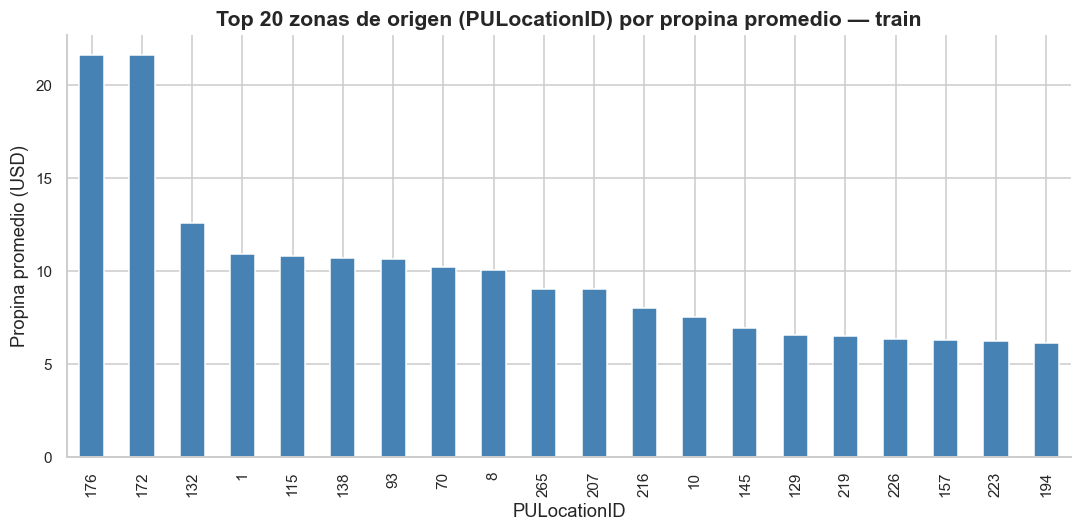

In [49]:
# Zonas (~260 valores, alta cardinalidad) -> TARGET ENCODING (Clase 4): cada zona se
# reemplaza por la propina media del train. Se ajusta SOLO en train; el test usa esas
# medias y, para zonas no vistas, la media global (evita fuga y NaNs).

# --- PULocationID / DOLocationID: target encoding (fit solo en train) ---
_y_train_idx = y_train.copy()
_y_train_idx.index = X_train_fe.index  # garantizamos alineación de índices

_pu_means    = _y_train_idx.groupby(X_train_fe['PULocationID']).mean()
_do_means    = _y_train_idx.groupby(X_train_fe['DOLocationID']).mean()
_media_global = _y_train_idx.mean()

X_train_fe['PU_target_enc'] = X_train_fe['PULocationID'].map(_pu_means).fillna(_media_global)
X_test_fe['PU_target_enc']  = X_test_fe['PULocationID'].map(_pu_means).fillna(_media_global)
X_train_fe['DO_target_enc'] = X_train_fe['DOLocationID'].map(_do_means).fillna(_media_global)
X_test_fe['DO_target_enc']  = X_test_fe['DOLocationID'].map(_do_means).fillna(_media_global)

# Eliminamos las columnas categóricas originales (reemplazadas)
_cols_drop = ['VendorID', 'RatecodeID', 'PULocationID', 'DOLocationID']
X_train_fe = X_train_fe.drop(columns=_cols_drop)
X_test_fe  = X_test_fe.drop(columns=_cols_drop)

# Concatenamos los dummies
X_train_enc = pd.concat([X_train_fe, _vendor_tr, _rate_tr], axis=1)
X_test_enc  = pd.concat([X_test_fe,  _vendor_te, _rate_te], axis=1)
X_train_enc.columns = X_train_enc.columns.astype(str)
X_test_enc.columns  = X_test_enc.columns.astype(str)

print("\nMatriz codificada:")
print(f"  X_train_enc: {X_train_enc.shape}  |  X_test_enc: {X_test_enc.shape}")
print(f"  Columnas: {list(X_train_enc.columns)}")

# --- Visualización: top-20 zonas de origen por propina promedio ---
fig, ax = plt.subplots(figsize=(10, 5))
_pu_means.sort_values(ascending=False).head(20).plot.bar(ax=ax, color='steelblue')
ax.set_title('Top 20 zonas de origen (PULocationID) por propina promedio — train')
ax.set_xlabel('PULocationID')
ax.set_ylabel('Propina promedio (USD)')
plt.tight_layout()
plt.show()

**Conclusión.** Cada categórica recibió el encoding apropiado a su cardinalidad (Clase 4): binaria/one-hot para las de pocas categorías, **target encoding** para las zonas de alta cardinalidad —donde one-hot crearía cientos de columnas. El gráfico muestra que las zonas tienen propinas promedio muy distintas: la geografía **sí** aporta señal.

### 5.5 Distribución del target y balance de clases (Clase 4/5)

**Concepto.** La consigna pide analizar **balance/desbalance** *en problemas de clasificación*. El nuestro es **regresión**, así que el balance de clases **no aplica**. Lo que sí miramos es la **forma** del target: es muy asimétrico. Mostramos la versión `log1p` como referencia (transformación logarítmica, Clase 4), aunque no la usemos, para no perder interpretabilidad en dólares.

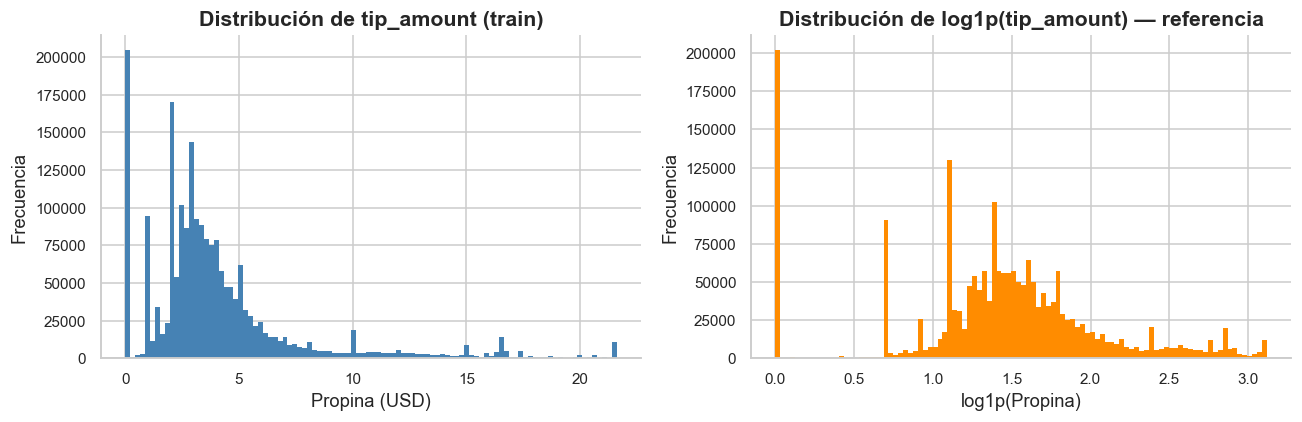

Asimetría (skewness) de tip_amount:        2.19
Asimetría de log1p(tip_amount):            -0.23
Proporción de viajes con propina > 0:      90.2 %


In [50]:
# Distribución del target y su versión log1p (referencia). En regresión NO hay
# balanceo de clases (Clase 4/5: el balanceo es para clasificación).

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y_train, bins=100, color='steelblue', edgecolor='none')
axes[0].set_title('Distribución de tip_amount (train)')
axes[0].set_xlabel('Propina (USD)')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(np.log1p(y_train), bins=100, color='darkorange', edgecolor='none')
axes[1].set_title('Distribución de log1p(tip_amount) — referencia')
axes[1].set_xlabel('log1p(Propina)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

print(f"Asimetría (skewness) de tip_amount:        {y_train.skew():.2f}")
print(f"Asimetría de log1p(tip_amount):            {np.log1p(y_train).skew():.2f}")
print(f"Proporción de viajes con propina > 0:      {(y_train > 0).mean()*100:.1f} %")

### 5.4 Distribución del target y balance de clases

Se trata de un **problema de regresión**, por lo que no aplica el análisis de balance de clases. Sin embargo, la distribución del target (`tip_amount`) es fuertemente asimétrica a la derecha: la mayoría de las propinas son pequeñas y existe una cola larga de propinas altas. Presentamos la distribución original y su versión transformada con `log1p` para ilustrar la asimetría.

> No aplicamos la transformación logarítmica al target en el pipeline definitivo porque queremos preservar la **interpretabilidad en dólares** al evaluar el modelo (RMSE en USD es directamente interpretable).

### 5.6 Escalado / estandarización (Clase 5)

**Concepto.** Muchos algoritmos (los que dependen de distancias o asumen normalidad, Clase 5) necesitan que las features estén en **escalas comparables**. La Clase 5 enseña dos opciones: **Normalización (MinMax)** a [0,1] y **Estandarización (Z-score)** a media 0 / desvío 1.

Usamos **Estandarización (Z-score)** —`X' = (X − μ) / σ`—. Es válida acá porque **ya winsorizamos las colas** en §4.5, así que μ y σ dejaron de estar dominadas por outliers. Escalamos **solo las columnas continuas**; las dummies (0/1), los indicadores binarios y los sin/cos (ya en [−1,1]) **no se escalan** (Clase 5: las codificaciones 0/1 y cíclicas no se reescalan). El escalador se ajusta **solo en train**.

In [51]:
# Estandarización Z-score (Clase 5): media 0, desvío 1. Se reemplaza el RobustScaler
# por StandardScaler para usar una de las dos técnicas canónicas de la materia.
from sklearn.preprocessing import StandardScaler

# Solo columnas CONTINUAS: las dummies/indicadores/sin-cos NO se escalan (Clase 5).
_cols_numericas = ['trip_distance', 'duration_min', 'fare_amount', 'passenger_count',
                   'speed_mph', 'fare_per_mile', 'PU_target_enc', 'DO_target_enc']

_scaler_fe = StandardScaler()
X_train_enc_esc = X_train_enc.copy()
X_test_enc_esc  = X_test_enc.copy()
X_train_enc_esc[_cols_numericas] = _scaler_fe.fit_transform(X_train_enc_esc[_cols_numericas])  # fit SOLO train
X_test_enc_esc[_cols_numericas]  = _scaler_fe.transform(X_test_enc_esc[_cols_numericas])        # apply test

print('Matriz final tras Feature Engineering + escalado:')
print(f'  X_train_enc_esc: {X_train_enc_esc.shape}   y_train: {y_train.shape}')
print(f'  X_test_enc_esc:  {X_test_enc_esc.shape}    y_test:  {y_test.shape}')
print(f'\nColumnas finales ({X_train_enc_esc.shape[1]}):')
for col in X_train_enc_esc.columns:
    print(f'  - {col}')
X_train_enc_esc.head()

Matriz final tras Feature Engineering + escalado:
  X_train_enc_esc: (2036220, 20)   y_train: (2036220,)
  X_test_enc_esc:  (509055, 20)    y_test:  (509055,)

Columnas finales (20):
  - trip_distance
  - duration_min
  - fare_amount
  - passenger_count
  - speed_mph
  - fare_per_mile
  - es_aeropuerto
  - es_hora_pico
  - hour_sin
  - hour_cos
  - dow_sin
  - dow_cos
  - PU_target_enc
  - DO_target_enc
  - vendor_2
  - rate_2.0
  - rate_3.0
  - rate_4.0
  - rate_5.0
  - rate_99.0


,trip_distance,duration_min,fare_amount,passenger_count,speed_mph,fare_per_mile,es_aeropuerto,es_hora_pico,hour_sin,hour_cos,dow_sin,dow_cos,PU_target_enc,DO_target_enc,vendor_2,rate_2.0,rate_3.0,rate_4.0,rate_5.0,rate_99.0
103344,-0.351151,-0.304923,-0.361554,-0.358714,-0.279656,-0.132057,0,0,0.258819,-9.659258e-01,0.000000,1.000000,-0.140673,1.350022,True,False,False,False,False,False
1924904,-0.147153,-0.262172,-0.188283,1.250421,0.321603,-0.252598,0,0,-0.500000,-8.660254e-01,-0.433884,-0.900969,-0.262744,-0.566853,False,False,False,False,False,False
2809771,-0.209743,0.273331,0.028305,-0.358714,-0.602585,-0.052864,0,1,-1.000000,-1.836970e-16,-0.781831,0.623490,-0.086205,-0.288674,True,False,False,False,False,False
363419,0.038299,0.380207,0.028305,-0.358714,-0.206310,-0.284623,0,0,-0.500000,8.660254e-01,0.974928,-0.222521,-0.215510,-0.145167,False,False,False,False,False,False
1605994,-0.682646,-0.732426,-0.751412,-0.358714,-1.045838,0.631407,0,0,-0.707107,-7.071068e-01,0.781831,0.623490,-0.086205,-0.216725,True,False,False,False,False,False


**Conclusión de la Sección 5.** Tenemos la **matriz de features definitiva**: variables nuevas justificadas, temporales codificadas de forma cíclica, categóricas codificadas según su cardinalidad y continuas estandarizadas (Z-score) — todo ajustado en train y aplicado al test sin fuga. Lista para la reducción de dimensionalidad.

---
# 6. Reducción de dimensionalidad

**De qué se trata esta sección.** La consigna pide dos cosas distintas (Clase 6):
1. **Selección de features** con mecanismos de **filtro** → quedarnos con un subconjunto de variables originales según su relevancia.
2. **Extracción de features** con **PCA** → transformar a un espacio de menos dimensiones, evaluando ventajas y desventajas.

Hacemos ambas: primero el análisis de **relevancia predictiva por filtros**, después el **PCA**.

### 6.1 Selección de features por filtros (Clase 6)

**Concepto.** Un **filtro** (Clase 6) puntúa cada feature por su relación con el target, sin entrenar ningún modelo. Combinamos dos:
- **Correlación robusta (|Spearman|)** feature ↔ target: capta relación **monótona** (Clase 2).
- **Información Mutua** (Clase 6): `I(X,Y) = H(Y) − H(Y|X)` — capta relación **no lineal**; es la base de `SelectKBest` para ordenar y quedarse con las **K mejores** features.

Como el cálculo de Información Mutua usa vecinos y es costoso, lo hacemos sobre una **muestra** del train (decisión de eficiencia explícita, no recorte silencioso).

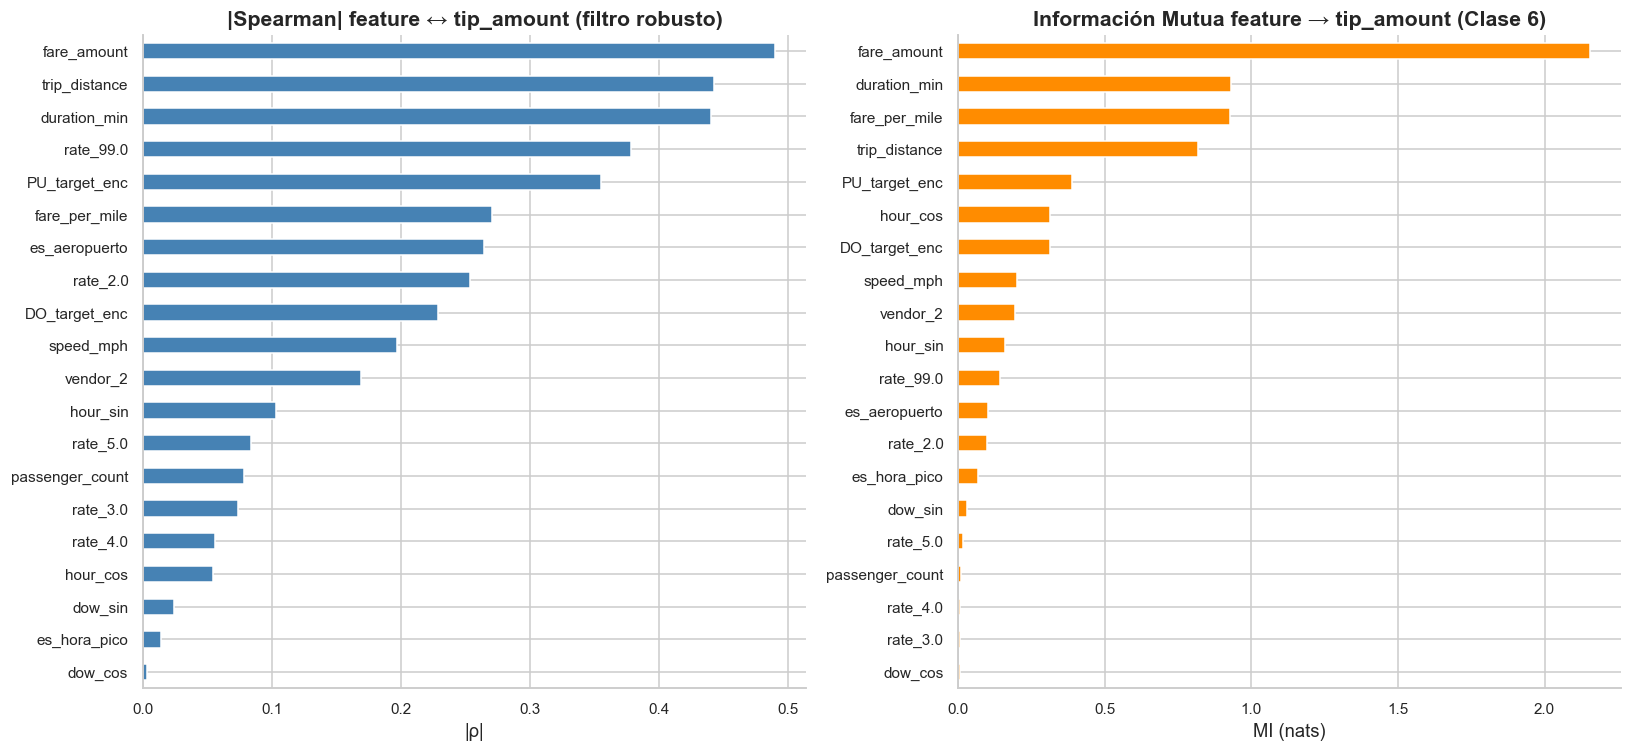

Top 5 por |Spearman|:         ['fare_amount', 'trip_distance', 'duration_min', 'rate_99.0', 'PU_target_enc']
Top 5 por Información Mutua:  ['fare_amount', 'duration_min', 'fare_per_mile', 'trip_distance', 'PU_target_enc']


In [52]:
# Filtros de selección de features (Clase 6): relevancia de cada feature vs el target.
from sklearn.feature_selection import mutual_info_regression

# Muestra del train (la Información Mutua con vecinos es cara sobre millones de filas).
_n = 80_000
_idx = np.random.default_rng(0).choice(len(X_train_enc_esc), size=_n, replace=False)
_Xs = X_train_enc_esc.iloc[_idx]
_ys = y_train.iloc[_idx].values          # alineado por posición con X_train_enc_esc

# (a) Filtro robusto: |Spearman| de cada feature con la propina (Clase 2)
_spear = _Xs.apply(lambda col: st.spearmanr(col, _ys)[0]).abs().sort_values(ascending=False)

# (b) Filtro de Información Mutua (Clase 6): relevancia no lineal feature -> target
_mi = pd.Series(mutual_info_regression(_Xs, _ys, random_state=0),
                index=_Xs.columns).sort_values(ascending=False)

# Visualización de ambos rankings, lado a lado
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
_spear.plot.barh(ax=axes[0], color='steelblue'); axes[0].invert_yaxis()
axes[0].set_title('|Spearman| feature ↔ tip_amount (filtro robusto)'); axes[0].set_xlabel('|ρ|')
_mi.plot.barh(ax=axes[1], color='darkorange'); axes[1].invert_yaxis()
axes[1].set_title('Información Mutua feature → tip_amount (Clase 6)'); axes[1].set_xlabel('MI (nats)')
plt.tight_layout(); plt.show()

print('Top 5 por |Spearman|:        ', list(_spear.head(5).index))
print('Top 5 por Información Mutua: ', list(_mi.head(5).index))

**Conclusión del filtro.** Los dos rankings coinciden en lo esencial (ver salida): las features de **tarifa/escala del viaje** (`fare_amount`, `fare_per_mile`, `trip_distance`, `duration_min`) y las **zonas codificadas por target** encabezan la relevancia hacia la propina, mientras que los indicadores binarios y algunas cíclicas aportan poco por sí solas. Esto da un criterio de **selección**: si hiciera falta achicar la matriz, descartaríamos primero las de menor relevancia en *ambos* filtros. Lo cruzamos a continuación con la visión de **extracción** del PCA.

### 6.2 Extracción de features con PCA (Clase 6)

**Concepto.** El **PCA** (Clase 6) no elige features: **crea ejes nuevos** (componentes principales) que son combinaciones lineales de las originales, ordenados por la **varianza** que capturan. Sirve para medir **redundancia** y, eventualmente, reducir dimensión. Lo ajustamos sobre la matriz de train ya escalada.

> ⚠️ **Recordatorio (Clase 6): PCA asume relaciones lineales y requiere datos estandarizados** — por eso lo corremos después del Z-score de §5.6.

In [53]:
# Ajustamos PCA con tantos componentes como features, para ver el espectro completo
# de varianza. loadings = contribución de cada variable original a cada componente.

from sklearn.decomposition import PCA

pca = PCA(n_components=X_train_enc_esc.shape[1])
pca.fit(X_train_enc_esc)

loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=X_train_enc_esc.columns
)
loadings.round(3).head(20)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20
trip_distance,0.501,-0.093,0.050,-0.078,0.038,0.002,0.086,0.069,0.083,0.087,0.007,-0.038,-0.402,-0.464,-0.492,-0.276,-0.023,0.076,-0.003,0.000
duration_min,0.402,-0.203,0.369,-0.411,0.067,-0.087,0.046,0.144,-0.072,-0.160,0.010,-0.032,0.488,-0.167,0.378,-0.118,-0.005,0.046,0.028,-0.000
fare_amount,0.493,0.064,0.190,-0.080,0.081,-0.024,0.053,0.067,0.024,0.020,-0.007,-0.127,-0.249,0.735,-0.075,0.226,0.037,-0.132,-0.036,0.000
passenger_count,0.027,0.525,-0.454,-0.702,-0.030,0.077,-0.037,-0.036,0.105,0.027,0.013,0.051,0.007,-0.004,-0.002,-0.001,0.002,-0.002,-0.000,0.000
speed_mph,0.381,0.005,-0.397,0.361,-0.094,0.151,0.212,0.031,0.418,0.402,-0.032,-0.024,0.295,-0.016,0.249,-0.012,0.004,-0.001,0.011,-0.000
fare_per_mile,-0.099,0.697,0.478,0.208,0.324,0.017,0.204,0.152,0.182,0.070,-0.001,-0.005,0.053,-0.128,0.022,-0.067,0.017,-0.007,0.001,-0.000
es_aeropuerto,0.057,0.014,-0.004,0.005,0.022,-0.002,-0.011,-0.014,-0.022,-0.004,0.006,-0.021,-0.450,-0.176,0.487,0.213,0.279,0.243,0.089,-0.577
es_hora_pico,-0.012,-0.014,0.019,0.002,0.009,-0.011,-0.092,0.022,0.025,0.123,0.986,-0.038,0.011,0.011,0.004,-0.003,0.001,-0.001,-0.000,-0.000
hour_sin,0.010,-0.043,0.091,-0.002,-0.110,0.427,0.318,-0.466,0.360,-0.578,0.105,-0.031,-0.028,0.010,-0.009,-0.008,0.001,-0.000,-0.000,-0.000
hour_cos,0.016,0.033,-0.286,0.156,-0.016,-0.389,0.040,0.563,0.258,-0.592,0.061,0.024,-0.029,0.010,-0.012,0.010,0.003,-0.001,-0.001,-0.000


#### Varianza explicada — ¿cuántos componentes retener?

**Concepto.** El criterio de la Clase 6: retener los primeros componentes que acumulen **≥70–90% de la varianza** (método del codo / varianza acumulada). El gráfico de la izquierda muestra la varianza por componente; el de la derecha, la acumulada.

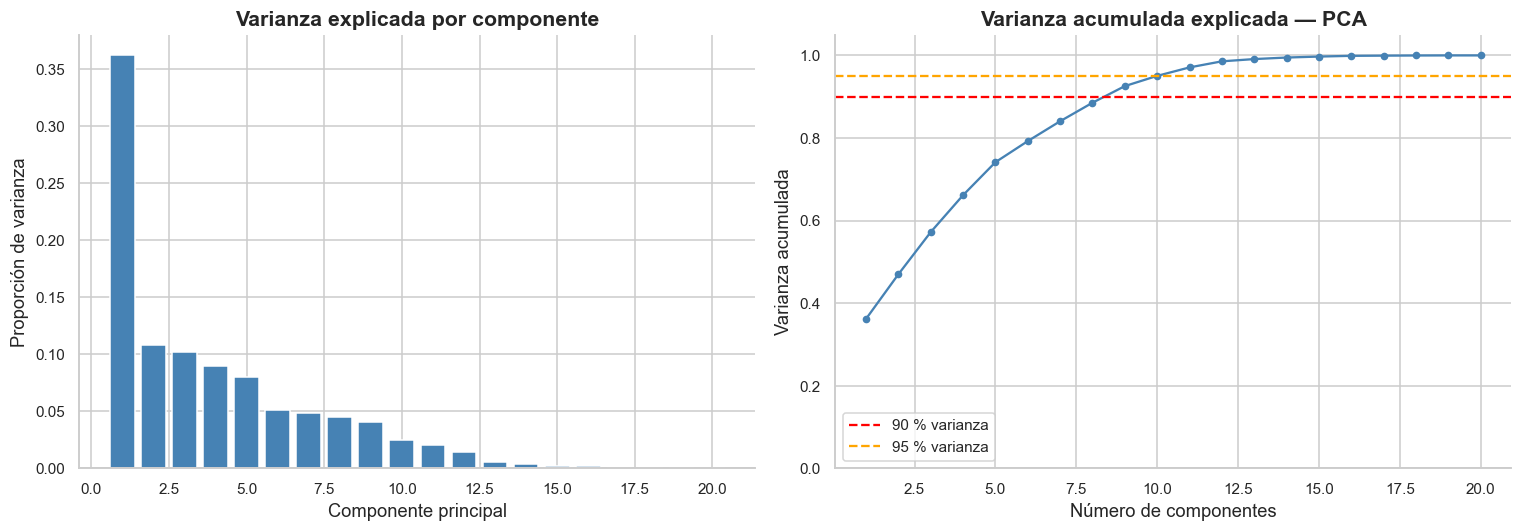

Varianza explicada por los primeros componentes (%):
  PC1: 36.2 %  (acumulada: 36.2 %)
  PC2: 10.8 %  (acumulada: 47.0 %)
  PC3: 10.2 %  (acumulada: 57.2 %)
  PC4: 8.9 %  (acumulada: 66.2 %)
  PC5: 8.0 %  (acumulada: 74.1 %)
  PC6: 5.1 %  (acumulada: 79.2 %)

Componentes para ≥90 % de varianza: 9 (de 20 features originales)
Componentes para ≥95 % de varianza: 10


In [54]:
# Varianza explicada por componente y acumulada (Clase 6): cuántos PCs para 90/95%.

_varianza = pca.explained_variance_ratio_
_varianza_acum = np.cumsum(_varianza)
_n_comp = len(_varianza_acum)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, _n_comp + 1), _varianza, color='steelblue')
axes[0].set_title('Varianza explicada por componente')
axes[0].set_xlabel('Componente principal')
axes[0].set_ylabel('Proporción de varianza')

axes[1].plot(range(1, _n_comp + 1), _varianza_acum, marker='o', markersize=4, color='steelblue')
axes[1].axhline(0.90, linestyle='--', color='red',    label='90 % varianza')
axes[1].axhline(0.95, linestyle='--', color='orange', label='95 % varianza')
axes[1].set_title('Varianza acumulada explicada — PCA')
axes[1].set_xlabel('Número de componentes')
axes[1].set_ylabel('Varianza acumulada')
axes[1].legend()
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

_n_90 = int(np.argmax(_varianza_acum >= 0.90) + 1)
_n_95 = int(np.argmax(_varianza_acum >= 0.95) + 1)

print('Varianza explicada por los primeros componentes (%):')
for i in range(min(6, _n_comp)):
    print(f'  PC{i+1}: {_varianza[i]*100:.1f} %  (acumulada: {_varianza_acum[i]*100:.1f} %)')
print(f'\nComponentes para ≥90 % de varianza: {_n_90} (de {_n_comp} features originales)')
print(f'Componentes para ≥95 % de varianza: {_n_95}')

**Conclusión del gráfico.** La curva acumulada (ver salida) indica cuántos componentes hacen falta para ~90–95% de la varianza de *X*. Que se necesiten **varios** componentes ya adelanta que **no hay una redundancia masiva** que justifique reducir agresivamente.

#### Loadings — ¿qué variables dominan cada componente?

**Concepto.** Los **loadings** (Clase 6) son el peso de cada variable original en cada componente. El heatmap permite *interpretar* qué representa cada eje.

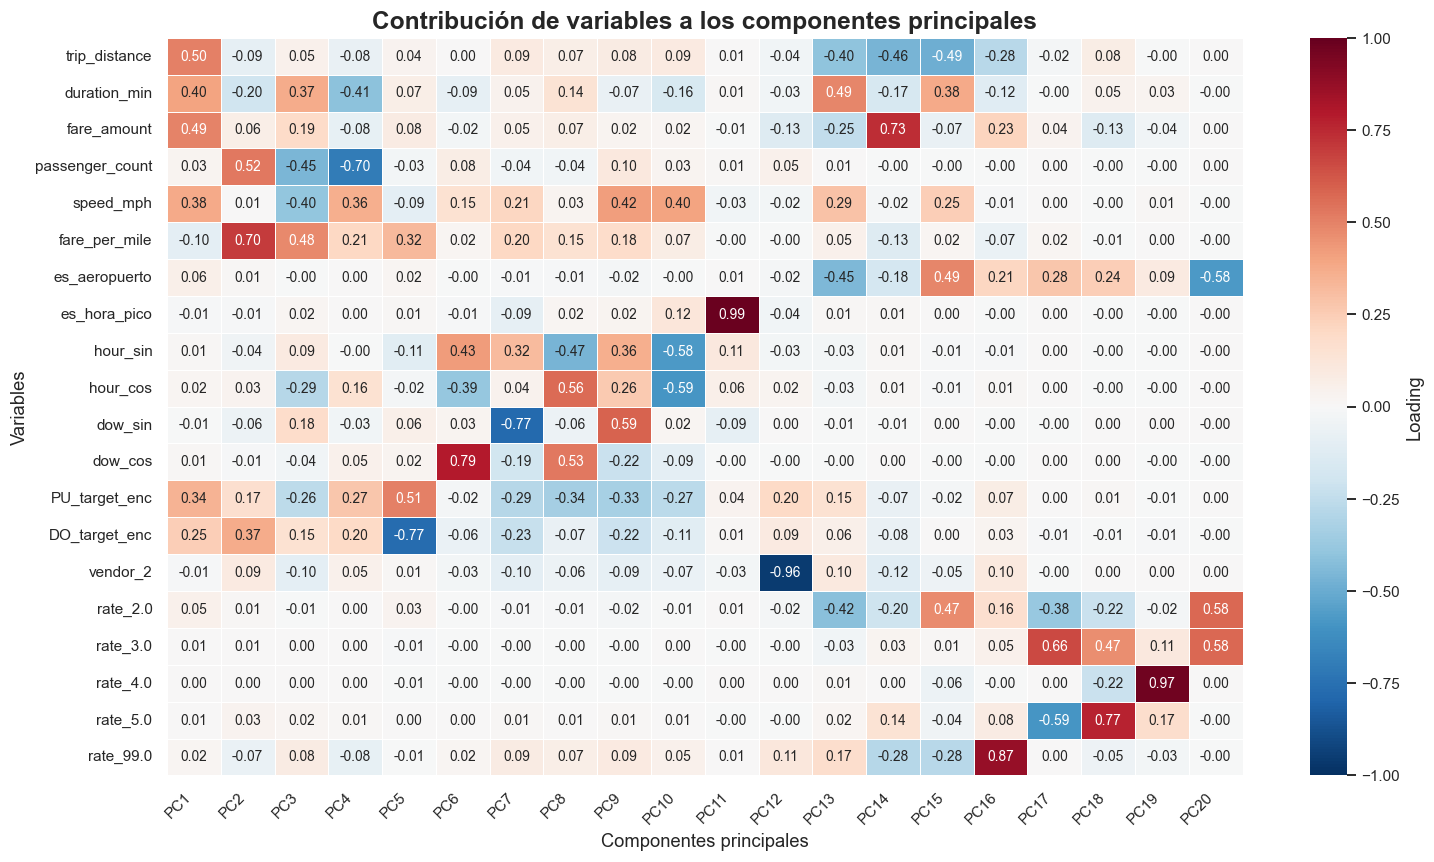

In [55]:
# Heatmap de loadings: qué variables 'empujan' cada componente principal (Clase 6).

plt.figure(figsize=(14, 8))

sns.heatmap(
    loadings,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={'label': 'Loading'},
    annot_kws={'size': 9}
)

plt.title('Contribución de variables a los componentes principales', fontsize=16)
plt.xlabel('Componentes principales')
plt.ylabel('Variables')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [56]:
# Resumen textual: varianza y top-loadings de los primeros componentes.

print('Resumen de componentes principales (train):\n')
for i in range(min(6, pca.n_components_)):
    pc = f'PC{i+1}'
    top_vars = loadings[pc].abs().nlargest(4).index.tolist()
    print(f"  {pc}: {_varianza[i]*100:5.1f} % varianza  |  top loadings: {', '.join(top_vars)}")
print(f'\n→ {_n_90} PCs alcanzan ≥90 % varianza; {_n_95} PCs alcanzan ≥95 %.')

Resumen de componentes principales (train):

  PC1:  36.2 % varianza  |  top loadings: trip_distance, fare_amount, duration_min, speed_mph
  PC2:  10.8 % varianza  |  top loadings: fare_per_mile, passenger_count, DO_target_enc, duration_min
  PC3:  10.2 % varianza  |  top loadings: fare_per_mile, passenger_count, speed_mph, duration_min
  PC4:   8.9 % varianza  |  top loadings: passenger_count, duration_min, speed_mph, PU_target_enc
  PC5:   8.0 % varianza  |  top loadings: DO_target_enc, PU_target_enc, fare_per_mile, hour_sin
  PC6:   5.1 % varianza  |  top loadings: dow_cos, hour_sin, hour_cos, speed_mph

→ 9 PCs alcanzan ≥90 % varianza; 10 PCs alcanzan ≥95 %.


**Conclusión (interpretación de los ejes).** Según los loadings (ver salida), el **primer componente** concentra el **bloque de escala del viaje** (distancia, duración, tarifa, velocidad); los componentes siguientes reparten la **tarifa por milla**, el **conteo de pasajeros** y las **zonas** (target encoding), mientras que los indicadores binarios (`rate_*`, `vendor_*`, `es_*`) generan **ejes casi propios** de baja varianza. Es decir: el PCA *redistribuye* la información, pero **cada bloque de señal sigue presente** y repartido en varios ejes — lo que ya sugiere que comprimir mucho costaría información útil para el target.

#### Scores y biplot (PC1 vs PC2)

**Concepto.** Proyectamos una muestra del train sobre los dos primeros componentes (**scores**) y superponemos los vectores de loadings (**biplot**): muestra cómo se ordenan las observaciones y qué variables las empujan. Dos cuidados de lectura (consigna 7): (1) **recortamos los ejes a p1–p99** porque unos pocos outliers extremos en PC2 aplastarían el resto; (2) sacamos las etiquetas a una **columna a la derecha con líneas guía** para que no se superpongan.

In [57]:
# Scores: proyección de una muestra (10k) sobre los componentes principales.

_rng = np.random.default_rng(42)
_sample_idx = _rng.choice(len(X_train_enc_esc), size=10_000, replace=False)
_scores = pca.transform(X_train_enc_esc.iloc[_sample_idx])
scores = pd.DataFrame(
    _scores,
    columns=[f'PC{i+1}' for i in range(_scores.shape[1])]
)
scores[['PC1', 'PC2']].describe().round(2)

,PC1,PC2
count,10000.00,10000.00
mean,0.02,-0.02
std,1.96,0.93
min,-2.25,-2.92
25%,-1.13,-0.37
50%,-0.73,-0.18
75%,0.15,0.19
max,8.97,21.46


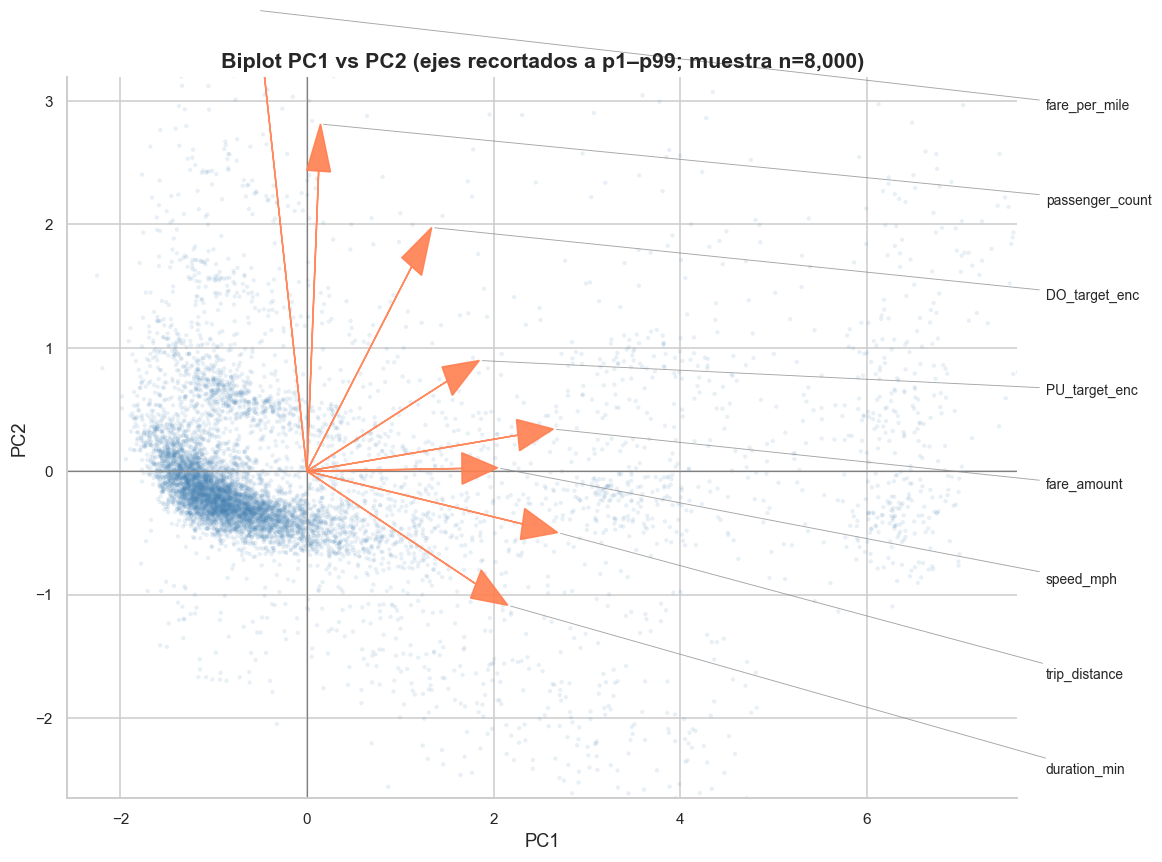

In [58]:
# Biplot LEGIBLE: nube de scores (recortada a p1-p99) + flechas de loadings con etiquetas
# en una columna lateral. El recorte evita que los outliers en PC2 aplasten el gráfico
# (consigna 7) y la columna de etiquetas evita la superposición de nombres.
def plot_biplot(scores, loadings, pcx='PC1', pcy='PC2', top_n=8, sample=8000):
    s = scores.sample(min(sample, len(scores)), random_state=0)
    xlo, xhi = scores[pcx].quantile([.01, .99])
    ylo, yhi = scores[pcy].quantile([.01, .99])
    dx, dy = xhi - xlo, yhi - ylo
    xlim = (xlo - 0.10 * dx, xhi + 0.10 * dx)
    ylim = (ylo - 0.12 * dy, yhi + 0.12 * dy)

    fig, ax = plt.subplots(figsize=(12, 8))
    plt.subplots_adjust(left=0.08, right=0.80, top=0.92, bottom=0.10)  # lugar a la derecha p/etiquetas
    ax.scatter(s[pcx], s[pcy], alpha=0.12, s=8, color='steelblue', edgecolors='none')

    # Variables más influyentes en este plano (PC1, PC2)
    importance = loadings[pcx] ** 2 + loadings[pcy] ** 2
    selected = importance.nlargest(top_n).index.tolist()

    # Escala UNIFORME de flechas (preserva ángulos) para que llenen el área visible
    scale = 0.80 * min(dx, dy) / np.sqrt(importance[selected]).max()

    # Etiquetas en una columna FUERA del área de datos (coords de eje), repartidas
    # uniformemente y ordenadas por la y de su flecha -> nunca se pisan ni se cortan.
    selected = sorted(selected, key=lambda f: loadings.loc[f, pcy])   # de abajo hacia arriba
    fracs = np.linspace(0.04, 0.96, len(selected))
    for frac, feat in zip(fracs, selected):
        x, y = loadings.loc[feat, pcx] * scale, loadings.loc[feat, pcy] * scale
        ax.arrow(0, 0, x, y, color='coral', alpha=0.9,
                 head_width=0.03 * dx, length_includes_head=True, zorder=3)
        ax.annotate(feat, xy=(x, y), xycoords='data',
                    xytext=(1.03, frac), textcoords='axes fraction',
                    fontsize=9, va='center', ha='left', annotation_clip=False,
                    arrowprops=dict(arrowstyle='-', color='gray', lw=0.6, alpha=0.7))

    ax.axhline(0, color='gray', lw=0.8); ax.axvline(0, color='gray', lw=0.8)
    ax.set_xlim(*xlim); ax.set_ylim(*ylim)
    ax.set_xlabel(pcx); ax.set_ylabel(pcy)
    ax.set_title(f'Biplot {pcx} vs {pcy} (ejes recortados a p1–p99; muestra n={len(s):,})')
    plt.show()

plot_biplot(scores, loadings, 'PC1', 'PC2')

**Conclusión del biplot.** Ya legible, confirma lo del heatmap de loadings: las flechas del **bloque de escala del viaje** (`fare_amount`, `trip_distance`, `duration_min`, `speed_mph`) apuntan casi horizontales → **definen PC1**, mientras que `fare_per_mile`, `passenger_count` y las **zonas** se inclinan hacia PC2. La nube **se abre en abanico hacia la derecha** sin formar grupos separados: no hay *clusters* limpios en este plano, coherente con que la varianza está repartida (hacen falta 9 PCs para el 90%). Es decir, el biplot **aporta como diagnóstico** —muestra que PC1 ≈ "tamaño del viaje"— pero refuerza que **comprimir a 2D pierde estructura**.

### 6.3 Conclusión — ¿conviene usar PCA para predecir la propina?

**Ventajas y desventajas (lo que pide la consigna):**

| Escenario | ¿PCA? | Por qué |
|---|---|---|
| **Modelos lineales (Ridge/Lasso)** | Puede ayudar | Estabiliza coeficientes ante multicolinealidad, pero **pierde interpretabilidad** (ya no se sabe cuánto aporta la zona vs. la distancia). |
| **Árboles (Random Forest, XGBoost)** | No necesario | Los árboles manejan bien la multicolinealidad y ~20 features; el PCA solo dificultaría explicar las predicciones. |
| **Visualización / diagnóstico** | Sí aporta | Resume la estructura y confirma redundancias del EDA. |

**Nuestra decisión:** **no** reducir con PCA para el modelado. Razones (Clase 6): (1) la varianza explicada mide dispersión de *X*, **no** poder predictivo sobre *y*; (2) mezclar señal geográfica con tarifaria en ejes ortogonales **destruye la interpretabilidad** que el negocio necesita; (3) los filtros de §6.1 ya nos dan un criterio de selección **interpretable**. Mantenemos las features originales post-encoding. El PCA queda como **herramienta de diagnóstico** (mostró que la señal está repartida, no concentrada en 2-3 ejes).

---
# 7. Resumen — dataset listo para modelado

**De qué se trata.** Cerramos el preprocesamiento. Tras §4 (limpieza), §5 (features) y §6 (diagnóstico), quedan **dos conjuntos alineados** listos para entrenar un regresor — **sin haber entrenado ningún modelo** (fuera del alcance de la consigna).

### Transformaciones aplicadas (todas: *fit* en train → *apply* en test)
1. **Filtro a tarjeta + limpieza** de registros imposibles (§4.1).
2. **Split 80/20** *antes* de transformar (§4.3) → sin *data leakage*.
3. **Winsorización** de features continuas a **p1–p99 del train**; cap del target en su cola superior (§4.5).
4. **Feature engineering** (§5): `speed_mph`, `fare_per_mile`, `es_aeropuerto`, `es_hora_pico` + codificación cíclica de hora/día.
5. **Encoding** (§5): binaria/one-hot de `VendorID`/`RatecodeID`; **target encoding** de zonas.
6. **Estandarización Z-score** (§5.6) de las columnas continuas (no `RobustScaler`: usamos una técnica canónica de la Clase 5).
7. **PCA** (§6): solo diagnóstico → **no** se usa como input; se mantienen las features originales.

La celda siguiente verifica la integridad del entregable (filas alineadas, sin NaN, mismas columnas en train/test).

In [59]:
# Verificación final del dataset entregable: tamaños, target post-cap y chequeos de integridad.

# --- Resumen final: train vs test listo para modelado ---

_particion = pd.DataFrame({
    'Conjunto': ['Train', 'Test', 'Total'],
    'Filas': [
        len(X_train_enc_esc),
        len(X_test_enc_esc),
        len(X_train_enc_esc) + len(X_test_enc_esc),
    ],
    'Features': [X_train_enc_esc.shape[1]] * 3,
    'Target': ['tip_amount (USD)'] * 3,
})
display(_particion.set_index('Conjunto'))

print('\n--- Target: y_train / y_test (post-cap p99.5 train) ---')
display(
    pd.concat([y_train.describe(), y_test.describe()], axis=1)
    .round(2)
    .rename(columns={0: 'y_train', 1: 'y_test'})
)
print(f"Propina > 0  →  train: {(y_train > 0).mean()*100:.1f} %  |  test: {(y_test > 0).mean()*100:.1f} %")

print(f'\n--- Features finales ({X_train_enc_esc.shape[1]} columnas) ---')
for i, col in enumerate(X_train_enc_esc.columns, 1):
    print(f'  {i:2d}. {col}')

print('\n--- Chequeos de integridad ---')
_checks = {
    'Misma cantidad de filas X ↔ y (train)': len(X_train_enc_esc) == len(y_train),
    'Misma cantidad de filas X ↔ y (test)':  len(X_test_enc_esc)  == len(y_test),
    'Mismas columnas train/test':            X_train_enc_esc.columns.equals(X_test_enc_esc.columns),
    'Sin NaN en X_train':                  X_train_enc_esc.isna().sum().sum() == 0,
    'Sin NaN en X_test':                   X_test_enc_esc.isna().sum().sum()  == 0,
    'Sin NaN en y_train':                  y_train.isna().sum() == 0,
    'Sin NaN en y_test':                   y_test.isna().sum()  == 0,
}
for k, v in _checks.items():
    print(f'  [{"OK" if v else "FAIL"}] {k}')

print('\n→ Próximo paso: elegir regresor, entrenar con (X_train_enc_esc, y_train) y evaluar en (X_test_enc_esc, y_test).')

,Filas,Features,Target
Conjunto,,,
Train,2036220,20,tip_amount (USD)
Test,509055,20,tip_amount (USD)
Total,2545275,20,tip_amount (USD)



--- Target: y_train / y_test (post-cap p99.5 train) ---


,tip_amount,tip_amount
count,2036220.00,509055.00
mean,4.10,4.11
std,3.75,3.76
min,0.00,0.00
25%,2.00,2.00
50%,3.20,3.21
75%,4.83,4.83
max,21.61,21.61


Propina > 0  →  train: 90.2 %  |  test: 90.2 %

--- Features finales (20 columnas) ---
   1. trip_distance
   2. duration_min
   3. fare_amount
   4. passenger_count
   5. speed_mph
   6. fare_per_mile
   7. es_aeropuerto
   8. es_hora_pico
   9. hour_sin
  10. hour_cos
  11. dow_sin
  12. dow_cos
  13. PU_target_enc
  14. DO_target_enc
  15. vendor_2
  16. rate_2.0
  17. rate_3.0
  18. rate_4.0
  19. rate_5.0
  20. rate_99.0

--- Chequeos de integridad ---
  [OK] Misma cantidad de filas X ↔ y (train)
  [OK] Misma cantidad de filas X ↔ y (test)
  [OK] Mismas columnas train/test
  [OK] Sin NaN en X_train
  [OK] Sin NaN en X_test
  [OK] Sin NaN en y_train
  [OK] Sin NaN en y_test

→ Próximo paso: elegir regresor, entrenar con (X_train_enc_esc, y_train) y evaluar en (X_test_enc_esc, y_test).


---
# 8. Conclusiones

**Síntesis del recorrido.** Este notebook **no entrena ni evalúa modelos** (fuera de alcance); las afirmaciones sobre qué "explica" la propina vienen del **EDA**, del **dominio** y de los **filtros/PCA** sobre *X*, no de un modelo ajustado sobre *y*.

### 8.1 Problema y target
- Planteamos **regresión de `tip_amount` (USD)** sobre viajes de **marzo 2026** del yellow cab de NYC.
- Restringir a **pagos con tarjeta** fue una decisión metodológica correcta: la propina en efectivo **no se registra** (MNAR, Clase 3). Incluir efectivo habría mezclado "medio de pago" con "comportamiento de propina".

### 8.2 Calidad y preprocesamiento
- El dataset crudo tiene **colas extremas y errores imposibles** → priorizamos **estadística robusta** (mediana, IQR, MAD, Spearman/Kendall — Clases 2 y 3) y separamos **errores a eliminar** de **outliers plausibles a acotar**.
- El pipeline evita **data leakage**: *split* 80/20 **antes** de transformar; todos los estadísticos se calculan **solo en train** (Clase 5).
- Winsorización por **p1–p99** (no IQR×1,5, para no borrar viajes de aeropuerto válidos). Escalado por **Z-score** (Clase 5).

### 8.3 Variables candidatas (sin modelado)
- **Tarifa y escala del viaje** (`fare_amount`, `fare_per_mile`, `trip_distance`, `duration_min`) encabezan los **filtros de relevancia** (§6.1): coherente con que se propina como % de la tarifa.
- **Geografía (zonas TLC):** negocio **Manhattan-céntrico** (~86%); el target encoding muestra propinas medias muy distintas por zona → la zona es **proxy** del tipo de viaje y perfil de pasajero.
- **Temporalidad:** hay patrones horarios visibles, pero de menor peso individual.

### 8.4 Reducción de dimensionalidad
- **Filtros (§6.1):** dieron un ranking de relevancia **interpretable** feature→target (Spearman + Información Mutua).
- **PCA (§6.2):** mostró que la señal está **repartida** en varios componentes (no concentrada en 2-3). Por eso, y por la pérdida de interpretabilidad, **no usamos PCA** como input del modelo; lo dejamos como diagnóstico.

### 8.5 Límites y próximos pasos
- El dataset **no registra** clima, eventos ni calidad del servicio → parte de la varianza de la propina será **irreducible** con estas variables.
- El pipeline deja `X_train_enc_esc` / `X_test_enc_esc` y `y_train` / `y_test` listos. El paso siguiente (fuera de este TP) sería **entrenar y comparar modelos** (Ridge, Random Forest, XGBoost) con métricas como MAE/RMSE en USD.